# Tutorial 3: Advanced Python, Scientific Libraries & Entering $\mathcal{C}\ell(2)$

### P&S: Gibbs? Clifford! · ETH Zürich

In this tutorial we will:
1. **Last Week Notes** — Revisit edge-cases from Class 2 (no `__init__`, operator overloading, properties, …)
2. **Advanced Python** — Inheritance, decorators, functional programming, generators, exception handling
3. **Essential Scientific Libraries** — Pandas and SymPy
4. **Exercises** — Orthogonal / parallel vectors, triple products, collecting results with Pandas
5. **Entering $\mathcal{C}\ell(2)$** — The geometric product in Python, the `SymbolicVector`, and `apply_rules`

---

## 0. Setup: Importing Libraries

> **Setup required:** In the `psgibbs` environment, after activating it with (windows powershell):
> ```
> .\psgibbs\Scripts\Activate.ps1
> ```
> please run the following to add the necessary libraries:
> ```
> pip install sympy pandas
> ```

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import pandas as pd
import sympy as sp
import random
import time
import itertools
from functools import reduce
from contextlib import contextmanager
from enum import Enum

print("Libraries imported successfully!")

Libraries imported successfully!


---
# Part 1: Last Week Notes

Before diving into new material, let's revisit some important edge-cases and clarifications from Class 2.

## 1.1 Class Without `__init__`

Python inherits a default empty `__init__` from the base `object` class, so instantiation works — but the resulting object has **no attributes** defined at creation.

In [1]:
class Empty:
    pass

obj = Empty()   # Works fine!
print(obj)      # <__main__.Empty object at 0x...>

In [2]:
# But the instance has no attributes defined at creation:
try:
    print(obj.x)
except AttributeError as e:
    print(f"AttributeError: {e}")

AttributeError: 'Empty' object has no attribute 'x'


In [3]:
# You CAN attach attributes afterwards, but it doesn't help other instances
obj.x = 10
print(f"obj.x = {obj.x}")

obj2 = Empty()
try:
    print(obj2.x)
except AttributeError as e:
    print(f"obj2 has no x: {e}")

obj.x = 10
obj2 has no x: 'Empty' object has no attribute 'x'


### 1.2 The Shared State Trap

When data is defined **directly in the class body** (without `self`), all instances **share** it.

In [9]:
class Broken:
    x = 1       # Class-level variable!

a = Broken()
b = Broken()

a.x = 99          # Looks like you changed a.x...
print(f"b.x = {b.x}")  # 1 — b is fine here

# But if you change it on the CLASS itself
Broken.x = 90
print(f"a.x = {a.x}")  # 99 (a had its own shadow, so still 99)
print(f"b.x = {b.x}")  # 90

Broken.y = 95 # changes both!
print(f"a.y = {a.y}")  # 95
print(f"b.y = {b.y}")  # 95

b.x = 1
a.x = 99
b.x = 90
a.y = 95
b.y = 95


In [247]:
# The correct pattern: always use self in __init__
class Fixed:
    def __init__(self, x):
        self.x = x   # Instance-level!

a = Fixed(1)
b = Fixed(1)

a.x = 99
print(f"b.x = {b.x}")  # 1 <- independent!

b.x = 1


### 1.3 When No `__init__` Makes Sense: Enumerators

In [248]:
class Direction(Enum):
    NORTH = "N"
    SOUTH = "S"
    EAST  = "E"
    WEST  = "W"

d = Direction.NORTH
print(d)          # Direction.NORTH
print(d.value)    # N
print(d.name)     # NORTH

if d == Direction.NORTH:
    print("Heading north!")

# Bug-prone:
# if direction == "nroth":   # typo, silent fail

# Safe:
# if direction == Direction.NORTH:  # typo = error

Direction.NORTH
N
NORTH
Heading north!


### 1.4 When No `__init__` Makes Sense: Static Namespaces

A class used purely to **group related functions** together. No instance is ever created.

In [249]:
class GAMath:
    @staticmethod
    def dot(u, v):
        return u[0]*v[0] + u[1]*v[1]

    @staticmethod
    def wedge(u, v):
        return u[0]*v[1] - u[1]*v[0]

# No instance needed:
v1 = (2, 1)
v2 = (1, 2)
print(f"dot   = {GAMath.dot(v1, v2)}")
print(f"wedge = {GAMath.wedge(v1, v2)}")

dot   = 4
wedge = 3


## 1.5 Initializer vs. Constructor

When you write `v = Vector(2, 1)`, Python actually runs **two** methods behind the scenes:

1. **`__new__` (Constructor):** Allocates a fresh, empty object in memory. You almost never write this yourself.
2. **`__init__` (Initializer):** Receives the already-existing object as `self` and populates it with attributes.

In [250]:
# Demonstrating the call order
class Demo:
    def __new__(cls, value):
        print(f"  __new__  called with value={value}")
        instance = super().__new__(cls)
        return instance

    def __init__(self, value):
        print(f"  __init__ called with value={value}")
        self.value = value

print("Creating Demo(42):")
d = Demo(42)
print(f"d.value = {d.value}")

Creating Demo(42):
  __new__  called with value=42
  __init__ called with value=42
d.value = 42


In [251]:
# Advanced use case: subclassing an immutable type
# By the time __init__ runs, int's value is already fixed,
# so validation must go in __new__.

class PositiveInt(int):
    def __new__(cls, value):
        if value <= 0:
            raise ValueError("Must be positive!")
        return super().__new__(cls, value)

x = PositiveInt(5)
print(f"x = {x}")

try:
    y = PositiveInt(-1)
except ValueError as e:
    print(f"ValueError: {e}")

x = 5
ValueError: Must be positive!


## 1.6 Operator Overloading

### `+` Without `__add__`: What Happens?

In [252]:
class VectorNoAdd:
    def __init__(self, x, y):
        self.x = x
        self.y = y

v1 = VectorNoAdd(2, 1)
v2 = VectorNoAdd(1, 2)

try:
    result = v1 + v2
except TypeError as e:
    print(f"TypeError: {e}")

TypeError: unsupported operand type(s) for +: 'VectorNoAdd' and 'VectorNoAdd'


### Making `__add__` Robust with `isinstance()`

In [253]:
class VectorRobust:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        if isinstance(other, VectorRobust):
            return VectorRobust(self.x + other.x, self.y + other.y)
        return NotImplemented  # tells Python: "I can't handle this, try the other operand."

    def __repr__(self):
        return f"VectorRobust({self.x}, {self.y})"

v1 = VectorRobust(2, 1)
v2 = VectorRobust(1, 2)
print(f"v1 + v2 = {v1 + v2}")

# isinstance() vs type(): isinstance respects inheritance
class VectorRobust3D(VectorRobust):
    pass

v3 = VectorRobust3D(1, 2)
print(f"isinstance(v3, VectorRobust) = {isinstance(v3, VectorRobust)}")  # True ✓
print(f"type(v3) == VectorRobust     = {type(v3) == VectorRobust}")       # False ✗

v1 + v2 = VectorRobust(3, 3)
isinstance(v3, VectorRobust) = True
type(v3) == VectorRobust     = False


### The Right-Hand Fallback Chain (`__rmul__`)

Consider `2 * v`. Python first tries `int.__mul__(2, v)`. But `int` doesn't know what to do, returning `NotImplemented`. Then, the *reflected* method is tried on the right part: `v.__rmul__(2)`.

In [254]:
class VectorNoRmul:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __mul__(self, scalar):
        return VectorNoRmul(self.x * scalar, self.y * scalar)

    def __repr__(self):
        return f"Vector({self.x}, {self.y})"

v = VectorNoRmul(3, 4)
print(f"v * 2 = {v * 2}")  # Works: calls v.__mul__(2)

try:
    print(f"2 * v = {2 * v}")  # Fails! int doesn't know VectorNoRmul
except TypeError as e:
    print(f"TypeError: {e}")

v * 2 = Vector(6, 8)
TypeError: unsupported operand type(s) for *: 'int' and 'VectorNoRmul'


In [255]:
# The fix: add __rmul__
class VectorWithRmul:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __mul__(self, scalar):
        return VectorWithRmul(self.x * scalar, self.y * scalar)

    def __rmul__(self, scalar):
        # For scalar multiplication, it's commutative
        return self.__mul__(scalar)

    def __repr__(self):
        return f"Vector({self.x}, {self.y})"

v = VectorWithRmul(3, 4)
print(f"v * 2 = {v * 2}")  # Vector(6, 8)
print(f"2 * v = {2 * v}")  # Vector(6, 8)  — now works!

v * 2 = Vector(6, 8)
2 * v = Vector(6, 8)


> **Warning:** For the geometric product, multiplication is **not** commutative! So `__rmul__` would need to be handled differently (e.g., `other.geometric_product(self)`).

## 1.7 Attributes vs. Properties

### The sync bug

In [256]:
# Problem: storing data in multiple places goes out of sync
class VectorBrokenSync:
    def __init__(self, x, y):
        self.x = x          # attribute
        self.y = y          # attribute
        self._array = np.array([x, y])

v = VectorBrokenSync(3, 4)
v.x = 10
# But v._array still holds the old value!
print(f"v.x = {v.x}")               # 10
print(f"v._array[0] = {v._array[0]}") # 3 <- stale!

v.x = 10
v._array[0] = 3


### The fix: Single Source of Truth with `@property`

A **property** looks like an attribute from the outside, but runs **code** behind the scenes.

In [257]:
class VectorFixed:
    def __init__(self, x, y):
        # Single source of truth
        self._array = np.array([x, y], dtype=float)

    @property
    def x(self):
        return self._array[0]

    @x.setter
    def x(self, value):
        self._array[0] = value

    @property
    def y(self):
        return self._array[1]

    @y.setter
    def y(self, value):
        self._array[1] = value

v = VectorFixed(3, 4)
print(f"v.x = {v.x}")               # 3.0
v.x = 10
print(f"v.x = {v.x}")               # 10.0
print(f"v._array[0] = {v._array[0]}") # 10.0  ✓ in sync!

v.x = 3.0
v.x = 10.0
v._array[0] = 10.0


## 1.8 Matplotlib: `plt.show()` and Figure Management

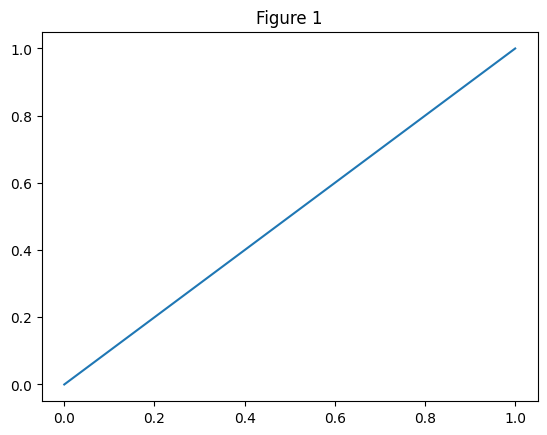

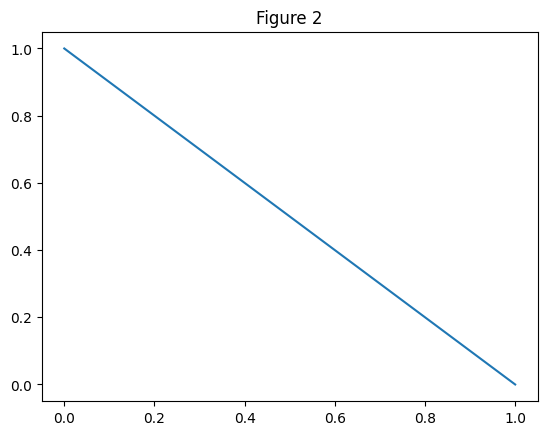

In [258]:
# Matplotlib keeps a list of all figures you've created
# plt.show() displays all of them
fig1, ax1 = plt.subplots()
ax1.plot([0, 1], [0, 1])
ax1.set_title("Figure 1")

fig2, ax2 = plt.subplots()
ax2.plot([0, 1], [1, 0])
ax2.set_title("Figure 2")

plt.show()   # Both windows appear at once!

# Important:
# - plt.show() clears figures from memory after displaying.
# - If you need to save AND show, always savefig first:
#   fig.savefig("plot.png")   # Save first
#   plt.show()                # Then show
#
# fig = canvas.  ax = drawing area.

---
# Part 2: Advanced Python

When building **software**, our code needs to survive the real world:
1. **Reusability** (DRY) — Inheritance & Decorators
2. **Efficiency** — Comprehensions, Lambdas, Functional Tools
3. **Scalability** — Generators (`yield`) & Context Managers (`with`)
4. **Robustness** — Exception Handling (`try-except`)

---

## 2.1 Reusability: Advanced OOP

### Inheritance

What if we want to build a 3D Vector? Instead of copy-pasting the entire `Vector2D` class, we use **Inheritance**.

In [259]:
# Parent class
class Vector2D_v0:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def print_type(self):
        print("I am a vector!")

# Child class — inherits everything from Vector2D_v0 automatically!
class Vector3D_v0(Vector2D_v0):
    def __init__(self, x, y, z):
        # Let the parent handle x and y
        super().__init__(x, y)
        # We only handle the new part
        self.z = z

v3 = Vector3D_v0(1, 2, 3)
print(f"v3.x = {v3.x}, v3.y = {v3.y}, v3.z = {v3.z}")
v3.print_type()  # "I am a vector!" — inherited!

v3.x = 1, v3.y = 2, v3.z = 3
I am a vector!


### Method Overriding

A 3D vector calculates its magnitude differently than a 2D vector. We can **override** the parent's method.

In [260]:
class Vector2D_v1:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def magnitude(self):
        return (self.x**2 + self.y**2)**0.5

class Vector3D_v1(Vector2D_v1):
    def __init__(self, x, y, z):
        super().__init__(x, y)
        self.z = z

    # Override magnitude for 3D
    def magnitude(self):
        return (self.x**2 + self.y**2 + self.z**2)**0.5

v2 = Vector2D_v1(3, 4)
v3 = Vector3D_v1(1, 2, 2)
print(f"2D magnitude: {v2.magnitude()}")  # 5.0
print(f"3D magnitude: {v3.magnitude()}")  # 3.0

2D magnitude: 5.0
3D magnitude: 3.0


### The Three Levels of Class Architecture

| Level | Name | Description |
|-------|------|-------------|
| **Instance** | The Object | Operates on unique data belonging to a single object (`self`) |
| **Class** | The Factory | Operates on the blueprint itself; shared by all objects (`cls`) |
| **Static** | The Toolbox | A normal function bundled inside the class for organization |

In [261]:
# Instance Level — what you already know
class VectorInstance:
    def __init__(self, x, y):
        self.x = x       # Instance variable (unique per object)
        self.y = y

    # Instance method — MUST take 'self' as first parameter
    def magnitude(self):
        return (self.x**2 + self.y**2)**0.5

v1 = VectorInstance(3, 4)
v2 = VectorInstance(1, 1)
print(f"v1.magnitude() = {v1.magnitude()}")  # 5.0
print(f"v2.magnitude() = {v2.magnitude()}")  # 1.414...

v1.magnitude() = 5.0
v2.magnitude() = 1.4142135623730951


In [262]:
# Class Level — shared by all objects
class VectorClass:
    dimension = 2  # Class variable! (Outside __init__)

    def __init__(self, x, y):
        self.x, self.y = x, y  # Instance variables

v1 = VectorClass(3, 4)
v2 = VectorClass(1, 1)

# Called on the class itself!
print(f"VectorClass.dimension = {VectorClass.dimension}")  # 2

# If we change the blueprint, it changes for ALL existing objects
VectorClass.dimension = 3
print(f"v1.dimension = {v1.dimension}")  # 3
print(f"v2.dimension = {v2.dimension}")  # 3

VectorClass.dimension = 2
v1.dimension = 3
v2.dimension = 3


In [263]:
# Static Level — just a utility function inside the class
class VectorStatic:
    def __init__(self, x, y):
        self.x, self.y = x, y

    # Without @staticmethod this would crash when called on an instance!
    @staticmethod
    def cross_2d(vec_a, vec_b):
        return vec_a.x * vec_b.y - vec_a.y * vec_b.x

v1 = VectorStatic(2, 0)
v2 = VectorStatic(0, 2)

# Both calling styles work with @staticmethod
print(f"VectorStatic.cross_2d(v1, v2) = {VectorStatic.cross_2d(v1, v2)}")  # 4
print(f"v1.cross_2d(v1, v2)           = {v1.cross_2d(v1, v2)}")            # 4

VectorStatic.cross_2d(v1, v2) = 4
v1.cross_2d(v1, v2)           = 4


In [264]:
# @classmethod — passes the blueprint (cls) instead of the object (self)
class VectorCls:
    dimension = 2

    @classmethod
    def get_dim(cls):
        return cls.dimension

print(f"VectorCls.get_dim() = {VectorCls.get_dim()}")  # 2

VectorCls.get_dim() = 2


### The `@property` Decorator

In [265]:
class VectorProp:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    @property
    def is_zero(self):
        return self.x == 0 and self.y == 0

v = VectorProp(0, 0)
# We treat it like an attribute — NO parentheses!
print(f"v.is_zero = {v.is_zero}")  # True

v2 = VectorProp(1, 2)
print(f"v2.is_zero = {v2.is_zero}")  # False

v.is_zero = True
v2.is_zero = False


### What is a Decorator Under the Hood?

Decorators are just **wrapper functions**. A decorator takes a function as input, adds some new behavior around it, and returns the modified function.

In [266]:
# Define the Wrapper
def my_decorator(func):
    def wrapper():
        print("Before the function!")
        func()  # Execute the original
        print("After the function!")
    return wrapper

# The Pythonic way using @ syntax
@my_decorator
def say_hello():
    print("Hello, Geometric Algebra!")

say_hello()
# Before the function!
# Hello, Geometric Algebra!
# After the function!

Before the function!
Hello, Geometric Algebra!
After the function!


### Decorating Methods: `*args` & `**kwargs`

Real methods take arguments (like `self` and `other`). To wrap them without crashing, our inner wrapper must accept **any** number of arguments.

In [267]:
# A decorator that logs our vector math
def log_math(func):
    # Accept ANY arguments
    def wrapper(*args, **kwargs):
        print(f"Running {func.__name__}")

        # Pass them down to the real function!
        result = func(*args, **kwargs)

        print("Finished")
        return result

    return wrapper

class VectorLog:
    def __init__(self, x, y):
        self.x, self.y = x, y

    @log_math
    def dot(self, other):
        return self.x * other.x + self.y * other.y

v1 = VectorLog(2, 3)
v2 = VectorLog(4, 1)

ans = v1.dot(v2)
print(f"Answer: {ans}")
# Running dot
# Finished
# Answer: 11

Running dot
Finished
Answer: 11


---
## 2.2 Where We Left Off: The Complete `Vector2D` Class

Here is the full `Vector2D` class from Class 2, now **fixed** to use `self.__class__` so inheritance works properly.

In [268]:
class Vector2D:
    """Complete 2D Vector for Geometric Algebra."""

    def __init__(self, x, y):
        self.x = x
        self.y = y
        self._array = np.array([x, y], dtype=float)

    def __str__(self):
        return f"Vector({self.x}, {self.y})"

    def __repr__(self):
        return f"Vector2D({self.x}, {self.y})"

    def __add__(self, other):
        a = self._array + other._array
        return self.__class__(*a)  # Fixed: uses self.__class__ instead of Vector2D

    def __sub__(self, other):
        a = self._array - other._array
        return self.__class__(*a)

    def __mul__(self, other):
        if type(other) == type(self):
            return self.geometric_product(other)
        # Scalar multiplication
        return self.__class__(*(self._array * other))

    def __rmul__(self, scalar):
        # Handles: 2 * v (scalar multiplication is commutative)
        return self.__mul__(scalar)

    def dot(self, other):
        # Uses np.dot — works for ANY dimension!
        return np.dot(self._array, other._array)

    def wedge(self, other):
        return self.x * other.y - self.y * other.x

    def geometric_product(self, other):
        return (self.dot(other), self.wedge(other))

    def magnitude(self):
        return np.linalg.norm(self._array)

    def normalize(self):
        mag = self.magnitude()
        if mag == 0:
            raise ValueError("Zero vector!")
        return self.__class__(*(self._array / mag))

    def angle_between(self, other, in_degrees=False):
        cos_t = np.clip(
            self.dot(other) / (self.magnitude() * other.magnitude()),
            -1.0, 1.0
        )
        rad = np.arccos(cos_t)
        return np.degrees(rad) if in_degrees else rad

    def plot(self, ax=None, **kwargs):
        if ax is None:
            fig, ax = plt.subplots()
            ax.set_aspect('equal')
        defaults = dict(
            angles='xy', scale_units='xy', scale=1,
            width=0.006, color='blue'
        )
        defaults.update(kwargs)
        ax.quiver(0, 0, self.x, self.y, **defaults)
        return ax

    # --- New features ---
    @staticmethod
    def are_parallel(v1, v2):
        return abs(v1.wedge(v2)) < 1e-10

    @staticmethod
    def are_orthogonal(v1, v2):
        return abs(v1.dot(v2)) < 1e-10

    @property
    def is_unit(self):
        return abs(self.magnitude() - 1.0) < 1e-10

    @classmethod
    def from_list(cls, coords):
        """Alternative constructor: acts as an 'Alternative Factory'."""
        return cls(*coords)  # cls adapts!

# Quick test
v1 = Vector2D(3, 4)
v2 = Vector2D(1, 2)

print(f"v1 = {v1}")
print(f"v1 + v2 = {v1 + v2}")
print(f"v1 - v2 = {v1 - v2}")
print(f"v1 * 2 = {v1 * 2}")
print(f"2 * v1 = {2 * v1}")
print(f"v1.dot(v2) = {v1.dot(v2)}")
print(f"v1.wedge(v2) = {v1.wedge(v2)}")
print(f"v1.geometric_product(v2) = {v1.geometric_product(v2)}")
print(f"v1.magnitude() = {v1.magnitude()}")
print(f"v1.normalize() = {v1.normalize()}")

v1 = Vector(3, 4)
v1 + v2 = Vector(4.0, 6.0)
v1 - v2 = Vector(2.0, 2.0)
v1 * 2 = Vector(6.0, 8.0)
2 * v1 = Vector(6.0, 8.0)
v1.dot(v2) = 11.0
v1.wedge(v2) = 2
v1.geometric_product(v2) = (np.float64(11.0), 2)
v1.magnitude() = 5.0
v1.normalize() = Vector(0.6, 0.8)


In [269]:
# Test the new features
e1 = Vector2D(1, 0)
e2 = Vector2D(0, 1)
v = Vector2D(2, 0)

print(f"are_parallel(e1, v) = {Vector2D.are_parallel(e1, v)}")    # True
print(f"are_orthogonal(e1, e2) = {Vector2D.are_orthogonal(e1, e2)}")  # True
print(f"e1.is_unit = {e1.is_unit}")  # True
print(f"v.is_unit  = {v.is_unit}")   # False

# from_list: alternative constructor
v_from_list = Vector2D.from_list([3, 4])
print(f"Vector2D.from_list([3, 4]) = {v_from_list}")

are_parallel(e1, v) = True
are_orthogonal(e1, e2) = True
e1.is_unit = True
v.is_unit  = False
Vector2D.from_list([3, 4]) = Vector(3, 4)


## 2.3 Exercise: Upgrading to `Vector3D`

### Step 1: Inherit Naively

In [270]:
class Vector3D(Vector2D):

    def __init__(self, x, y, z):
        # Parent sets self.x, self.y, self._array = np.array([x, y])
        super().__init__(x, y)
        # We only handle the new part
        self.z = z
        # Overwrite _array for 3D math
        self._array = np.array([x, y, z], dtype=float)

    def __repr__(self):
        return f"Vector3D({self.x}, {self.y}, {self.z})"

    def __str__(self):
        return f"Vector3D({self.x}, {self.y}, {self.z})"

    def wedge(self, other):
        """3D wedge: returns (e12, e13, e23) — three bivector components."""
        e12 = self.x * other.y - self.y * other.x
        e13 = self.x * other.z - self.z * other.x
        e23 = self.y * other.z - self.z * other.y
        return (e12, e13, e23)

    def plot(self, ax=None, **kwargs):
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
        defaults = dict(color='blue')
        defaults.update(kwargs)
        ax.quiver(0, 0, 0, self.x, self.y, self.z, **defaults)
        return ax

    @staticmethod
    def are_parallel(v1, v2):
        """Override: all 3 bivector components must vanish."""
        e12, e13, e23 = v1.wedge(v2)
        return (abs(e12) < 1e-10 and
                abs(e13) < 1e-10 and
                abs(e23) < 1e-10)

print("Vector3D defined successfully!")

Vector3D defined successfully!


In [271]:
# Test Vector3D: what works for free (from Vector2D)
v3a = Vector3D(1, 0, 0)
v3b = Vector3D(0, 1, 0)

# magnitude works! (uses self._array)
print(f"v3a.magnitude() = {v3a.magnitude()}")  # 1.0

# Addition works thanks to self.__class__!
v3c = v3a + v3b
print(f"v3a + v3b = {v3c}")
print(f"type(v3c) = {type(v3c).__name__}")  # Vector3D ✓

# dot works (uses _array)
print(f"v3a.dot(v3b) = {v3a.dot(v3b)}")  # 0.0

# wedge works (overridden)
print(f"v3a.wedge(v3b) = {v3a.wedge(v3b)}")  # (1, 0, 0) -> pure e12

# normalize works
v3d = Vector3D(1, 2, 2)
print(f"v3d.normalize() = {v3d.normalize()}")

# from_list adapts because cls is Vector3D!
v3_from_list = Vector3D.from_list([1, 2, 3])
print(f"Vector3D.from_list([1, 2, 3]) = {v3_from_list}")
print(f"type = {type(v3_from_list).__name__}")  # Vector3D

v3a.magnitude() = 1.0
v3a + v3b = Vector3D(1.0, 1.0, 0.0)
type(v3c) = Vector3D
v3a.dot(v3b) = 0.0
v3a.wedge(v3b) = (1, 0, 0)
v3d.normalize() = Vector3D(0.3333333333333333, 0.6666666666666666, 0.6666666666666666)
Vector3D.from_list([1, 2, 3]) = Vector3D(1, 2, 3)
type = Vector3D


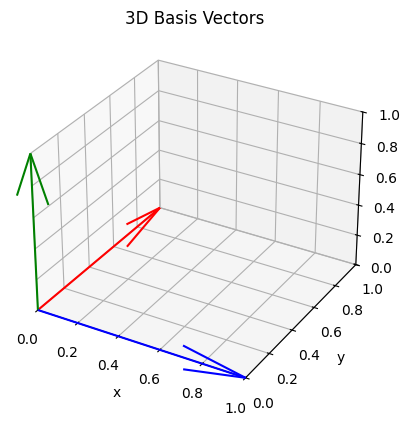

In [272]:
# Test 3D plotting
e1_3d = Vector3D(1, 0, 0)
e2_3d = Vector3D(0, 1, 0)
e3_3d = Vector3D(0, 0, 1)

ax = e1_3d.plot(color='blue')
e2_3d.plot(ax=ax, color='red')
e3_3d.plot(ax=ax, color='green')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('3D Basis Vectors')
plt.show()

### What Works For Free vs What Needs Override

| Works for free | Why | Needs override | Why |
|---|---|---|---|
| `magnitude` | `_array` is 3D | `__init__` | needs `self.z` + 3D `_array` |
| `dot` | uses `_array` | `__repr__`/`__str__` | must show `z` |
| `angle_between` | calls `dot` | `wedge` | different structure in 3D |
| `normalize` | uses `_array` | `plot` | 2D axes → 3D axes |
| `__add__`, `__sub__` | `self.__class__` | `are_parallel` | tuple `abs()` crash |
| `__mul__` (scalar) | `self.__class__` | | |

---
## 2.4 Efficiency: Functional Programming

### List Comprehensions

In [273]:
# The old way (slow):
squares_old = []
for x in range(5):
    squares_old.append(x**2)
print(f"Old way:  {squares_old}")

# List comprehension (fast):
squares = [x**2 for x in range(5)]
print(f"New way:  {squares}")

# Filtering with if:
evens = [x**2 for x in range(5) if x % 2 == 0]
print(f"Even sq:  {evens}")  # [0, 4, 16]

Old way:  [0, 1, 4, 9, 16]
New way:  [0, 1, 4, 9, 16]
Even sq:  [0, 4, 16]


### Dictionary Comprehensions

In [274]:
# Map vector index to its magnitude
vectors_demo = [Vector2D(3, 4), Vector2D(1, 1), Vector2D(0, 5)]

mag_dict = {
    f"vec_{i}": v.magnitude()
    for i, v in enumerate(vectors_demo)
}
print(mag_dict)

{'vec_0': np.float64(5.0), 'vec_1': np.float64(1.4142135623730951), 'vec_2': np.float64(5.0)}


### Lambda Functions (Anonymous Functions)

In [275]:
# Standard function
def square(x):
    return x ** 2

print(f"square(5) = {square(5)}")

# Lambda (anonymous) function
square_lambda = lambda x: x ** 2
print(f"lambda(5) = {square_lambda(5)}")

# Multiple arguments
add = lambda a, b: a + b
print(f"add(3, 7) = {add(3, 7)}")

square(5) = 25
lambda(5) = 25
add(3, 7) = 10


### Functional Tools: `map`, `filter`, `sorted`

In [276]:
nums = [1, 2, 3, 4, 5]

# map: applies function to every item
sq = list(map(lambda x: x**2, nums))
print(f"map (squares):  {sq}")

# filter: keeps items where function returns True
evens = list(filter(lambda x: x % 2 == 0, nums))
print(f"filter (evens): {evens}")

# sorted: sort complex objects by a rule
vectors_sort = [Vector2D(3, 4), Vector2D(1, 1), Vector2D(0, 5)]
ordered = sorted(vectors_sort, key=lambda v: v.magnitude())
print(f"sorted by mag:  {[str(v) for v in ordered]}")

map (squares):  [1, 4, 9, 16, 25]
filter (evens): [2, 4]
sorted by mag:  ['Vector(1, 1)', 'Vector(3, 4)', 'Vector(0, 5)']


### `functools.reduce`

In [277]:
nums = [1, 2, 3, 4]

# Multiply all numbers together: (((1 * 2) * 3) * 4) = 24
product = reduce(lambda a, b: a * b, nums)
print(f"reduce (product): {product}")

reduce (product): 24


### Advanced Function Arguments (`/` and `*`)

In [278]:
# / means: everything before me is Positional Only
# * means: everything after me is Keyword Only

def create_vector(x, y, /, *, is_3d=False):
    if is_3d:
        return (x, y, 0)
    return (x, y)

# CORRECT:
print(create_vector(2, 3, is_3d=True))

# ERROR! x and y must be positional:
try:
    create_vector(x=2, y=3, is_3d=True)
except TypeError as e:
    print(f"TypeError: {e}")

# ERROR! is_3d must be a keyword:
try:
    create_vector(2, 3, True)
except TypeError as e:
    print(f"TypeError: {e}")

(2, 3, 0)
TypeError: create_vector() got some positional-only arguments passed as keyword arguments: 'x, y'
TypeError: create_vector() takes 2 positional arguments but 3 were given


In [279]:
# The ultimate signature
def complex_func(
    pos_only, /,
    normal,
    *args,
    kw_only,
    **kwargs
):
    print(f"pos_only={pos_only}, normal={normal}, args={args}, kw_only={kw_only}, kwargs={kwargs}")

complex_func(1, 2, 3, 4, kw_only="hello", extra="world")

pos_only=1, normal=2, args=(3, 4), kw_only=hello, kwargs={'extra': 'world'}


In [280]:
# Advanced argument passing examples
def func(a, b, c, d, e, f):
    print(a, b, c, d, e, f)

func(1, *(2, 3), f=6, *(4, 5))
func(*(1, 2), e=5, *(3, 4), f=6)
func(1, **{"b": 2, "c": 3}, d=4, **{"e": 5, "f": 6})
func(c=3, *(1, 2), **{"d": 4}, e=5, **{"f": 6})
func(f=7, *[1, 2, 3], **{"d": 5, "e": 6})

1 2 3 4 5 6
1 2 3 4 5 6
1 2 3 4 5 6
1 2 3 4 5 6
1 2 3 5 6 7


### Exercise: Processing a Field of Vectors

In [281]:
# Dataset setup
random.seed(42)
vectors = [Vector2D(random.randint(-5, 5), random.randint(-5, 5)) for _ in range(20)]
e1 = Vector2D(1, 0)  # reference direction

print(f"Generated {len(vectors)} vectors.")
print(f"First 5: {[str(v) for v in vectors[:5]]}")

Generated 20 vectors.
First 5: ['Vector(5, -4)', 'Vector(-5, -1)', 'Vector(-2, -2)', 'Vector(-3, -4)', 'Vector(5, 3)']


In [282]:
# 1. List Comprehension: compute all wedge products v ∧ e1
wedges = [v.wedge(e1) for v in vectors]
print(f"Wedge products (v ∧ e1): {wedges}")
print()
print("Geometric meaning: wedge(e1) = -v_y.")
print("A large |v ∧ e1| means v points mostly PERPENDICULAR to e1.")
print("Note: v.wedge(e1) and e1.wedge(v) give opposite signs — order matters!")

Wedge products (v ∧ e1): [4, 1, 2, 4, -3, -4, 5, 4, 2, -4, -3, -5, -1, -2, 1, 3, 0, 3, 0, 4]

Geometric meaning: wedge(e1) = -v_y.
A large |v ∧ e1| means v points mostly PERPENDICULAR to e1.
Note: v.wedge(e1) and e1.wedge(v) give opposite signs — order matters!


In [283]:
# 2. sorted + lambda: sort by |v ∧ e1| descending
most_perp = sorted(
    vectors,
    key=lambda v: abs(v.wedge(e1)),
    reverse=True
)

print(f"Most perpendicular: {most_perp[0]}  wedge={most_perp[0].wedge(e1)}")
print(f"Least perpendicular: {most_perp[-1]}  wedge={most_perp[-1].wedge(e1)}")

Most perpendicular: Vector(1, -5)  wedge=5
Least perpendicular: Vector(-2, 0)  wedge=0


In [284]:
# 3. Dict Comprehension: map index to dot product with e1
dot_map = {
    i: vectors[i].dot(e1)
    for i in range(len(vectors))
}
print(f"Dot map: {dot_map}")
print()
print("Geometric meaning: dot(e1) = v_x.")
print("A large value means v points strongly ALONG e1 (signed projection on x-axis).")

Dot map: {0: np.float64(5.0), 1: np.float64(-5.0), 2: np.float64(-2.0), 3: np.float64(-3.0), 4: np.float64(5.0), 5: np.float64(-4.0), 6: np.float64(1.0), 7: np.float64(-5.0), 8: np.float64(-2.0), 9: np.float64(3.0), 10: np.float64(-5.0), 11: np.float64(-2.0), 12: np.float64(3.0), 13: np.float64(-2.0), 14: np.float64(4.0), 15: np.float64(-5.0), 16: np.float64(1.0), 17: np.float64(-1.0), 18: np.float64(-2.0), 19: np.float64(-4.0)}

Geometric meaning: dot(e1) = v_x.
A large value means v points strongly ALONG e1 (signed projection on x-axis).


In [285]:
# 4. reduce: find the vector with maximum magnitude (no max() or sorted()!)
biggest = reduce(
    lambda a, b: a if a.magnitude() >= b.magnitude() else b,
    vectors
)
print(f"Largest: {biggest}  |v|={biggest.magnitude():.3f}")
print("reduce compares two vectors at a time, keeping the larger, until only the winner remains.")

Largest: Vector(5, -4)  |v|=6.403
reduce compares two vectors at a time, keeping the larger, until only the winner remains.


---
## 2.5 Scalability: Generators

### The Memory Problem

What if we need to process 10 million vectors? A standard list computes **everything immediately**, potentially crashing RAM. **Generators** produce values one-at-a-time using `yield`.

In [286]:
# The standard list approach (dangerous for large n)
def get_vectors_list(n):
    result = []
    for i in range(n):
        result.append(Vector2D(i, i))
    return result

# Generator function — uses yield instead of return
def generate_vectors(n):
    """Generates vectors one by one."""
    for i in range(n):
        print(f"  Generating vector {i}")
        yield Vector2D(i, i)

# 1. Creates the generator object (does NOT run the code!)
vec_gen = generate_vectors(3)
print(f"Generator object: {vec_gen}")

# 2. Ask for items one at a time
v0 = next(vec_gen)
print(f"Got: {v0}")

v1 = next(vec_gen)
print(f"Got: {v1}")

v2 = next(vec_gen)
print(f"Got: {v2}")

Generator object: <generator object generate_vectors at 0x000001BBDF81C3C0>
  Generating vector 0
Got: Vector(0, 0)
  Generating vector 1
Got: Vector(1, 1)
  Generating vector 2
Got: Vector(2, 2)


In [287]:
# for loops call next() automatically!
print("Using a for loop:")
for vec in generate_vectors(3):
    print(f"  Processing: {vec}")

Using a for loop:
  Generating vector 0
  Processing: Vector(0, 0)
  Generating vector 1
  Processing: Vector(1, 1)
  Generating vector 2
  Processing: Vector(2, 2)


### Generator Expressions

In [288]:
# List Comprehension (uses []): computes ALL values immediately
squares_list = [x**2 for x in range(10)]
print(f"List: {squares_list}")

# Generator Expression (uses ()): computes NOTHING yet — a blueprint
squares_gen = (x**2 for x in range(10))
print(f"Generator: {squares_gen}")

# Generates values only as needed
print(f"next: {next(squares_gen)}")  # 0
print(f"next: {next(squares_gen)}")  # 1
print(f"next: {next(squares_gen)}")  # 4

List: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
Generator: <generator object <genexpr> at 0x000001BBE03285F0>
next: 0
next: 1
next: 4


### Exhausting a Generator: `StopIteration`

In [289]:
def count_to_two():
    yield 1
    yield 2

gen = count_to_two()
print(next(gen))  # 1
print(next(gen))  # 2

# There are no more yields!
try:
    print(next(gen))
except StopIteration:
    print("StopIteration: Generator exhausted!")

# A for loop catches StopIteration automatically:
print("\nFor loop version:")
for item in count_to_two():
    print(f"  {item}")

1
2
StopIteration: Generator exhausted!

For loop version:
  1
  2


### The Iterator Protocol (OOP Approach)

In [290]:
class VectorGenerator:
    def __init__(self, limit):
        self.current = 0
        self.limit = limit

    def __iter__(self):
        return self  # Required

    def __next__(self):
        if self.current >= self.limit:
            raise StopIteration()
        # Create item, increment, return
        v = Vector2D(self.current, self.current)
        self.current += 1
        return v

# Works exactly like the yield function!
for vec in VectorGenerator(3):
    print(vec)

Vector(0, 0)
Vector(1, 1)
Vector(2, 2)


### Exercise: Infinite Rotation Stream

Left-multiplying by $\mathbf{e}_{12}$ rotates a vector by 90°: $(x, y) \to (-y, x)$.

In [291]:
def rotate_90(v):
    """Left-multiply by e12: (x, y) -> (-y, x)."""
    return Vector2D(-v.y, v.x)

In [292]:
# 1. Generator Function
def rotate_stream(v):
    current = v
    while True:
        yield current
        current = rotate_90(current)

# The generator never terminates — it produces values lazily, only when asked.
# yield hands the current vector out and pauses until the next next() call.

In [293]:
# 2. itertools.islice — safely fetch items from an infinite stream
v0 = Vector2D(3, 1)

for step, v in enumerate(itertools.islice(rotate_stream(v0), 5)):
    print(f"Step {step}: {v}")

# Step 0: Vector(3, 1)    <- original
# Step 1: Vector(-1, 3)   <- 90°
# Step 2: Vector(-3, -1)  <- 180°
# Step 3: Vector(1, -3)   <- 270°
# Step 4: Vector(3, 1)    <- back at the beginning!

Step 0: Vector(3, 1)
Step 1: Vector(-1, 3)
Step 2: Vector(-3, -1)
Step 3: Vector(1, -3)
Step 4: Vector(3, 1)


In [294]:
# 3. Generator Expression: lazily filter vectors with magnitude > 3
large_vecs = (
    v for v in vectors
    if v.magnitude() > 3
)
# Nothing computed yet! Values produced on demand.
print("Large vectors (magnitude > 3):")
for v in large_vecs:
    print(f"  {v}  |v|={v.magnitude():.2f}")

Large vectors (magnitude > 3):
  Vector(5, -4)  |v|=6.40
  Vector(-5, -1)  |v|=5.10
  Vector(-3, -4)  |v|=5.00
  Vector(5, 3)  |v|=5.83
  Vector(-4, 4)  |v|=5.66
  Vector(1, -5)  |v|=5.10
  Vector(-5, -4)  |v|=6.40
  Vector(3, 4)  |v|=5.00
  Vector(-5, 3)  |v|=5.83
  Vector(-2, 5)  |v|=5.39
  Vector(3, 1)  |v|=3.16
  Vector(4, -1)  |v|=4.12
  Vector(-5, -3)  |v|=5.83
  Vector(-1, -3)  |v|=3.16
  Vector(-4, -4)  |v|=5.66


In [295]:
# 4. Spot the Pattern
# The cycle length is 4. What algebraic identity does this confirm?
#
# e12^2 = -1
# e12^4 = (e12^2)^2 = (-1)^2 = +1
# => 4 x 90° = 360°
#
# The period-4 cycle is a direct consequence of e12^4 = 1.
# For 45° rotations the cycle length would be 8, since e12^8 = (e12^4)^2 = 1^2 = 1.

print("e12^2 = -1")
print("e12^4 = (e12^2)^2 = (-1)^2 = +1")
print("=> 4 × 90° = 360° => cycle length = 4")
print("For 45° rotations: cycle length = 8 (since e12^8 = 1)")

e12^2 = -1
e12^4 = (e12^2)^2 = (-1)^2 = +1
=> 4 × 90° = 360° => cycle length = 4
For 45° rotations: cycle length = 8 (since e12^8 = 1)


---
## 2.6 Robustness: Exception Handling

### The Problem: What is an Exception?

In [296]:
# When Python encounters an impossible operation, it STOPS and raises an Exception
v_test = Vector2D(2, 1)

try:
    result = v_test + "Apple"
except AttributeError as e:
    print(f"AttributeError: {e}")
    print("The program would have halted completely without try/except!")

AttributeError: 'str' object has no attribute '_array'
The program would have halted completely without try/except!


### Raising Exceptions: Defensive Programming

In [297]:
class VectorDefensive:
    def __init__(self, x, y):
        self.x, self.y = x, y

    def __add__(self, other):
        if not isinstance(other, VectorDefensive):
            raise TypeError(
                f"Cannot add VectorDefensive to {type(other).__name__}!"
            )
        return VectorDefensive(self.x + other.x, self.y + other.y)

v = VectorDefensive(2, 1)
try:
    v + "Apple"
except TypeError as e:
    print(f"Caught: {e}")
    # Clean, specific, human-readable error message!

Caught: Cannot add VectorDefensive to str!


### Defining Custom Exceptions

In [298]:
class DimensionError(Exception):
    """Raised when vector dimensions don't match."""
    pass

def check_dims(v1, v2):
    if len(v1) != len(v2):
        raise DimensionError(
            f"{len(v1)} != {len(v2)}"
        )

try:
    check_dims([1, 2], [1, 2, 3])
except DimensionError as e:
    print(f"DimensionError: {e}")  # 2 != 3

DimensionError: 2 != 3


### Catching Exceptions: `try` and `except`

In [299]:
# Without handling:
try:
    result = 10 / 0
except ZeroDivisionError:
    print("Warning: divided by zero!")
    result = 0  # safe fallback

print(f"Result is {result}")

Result is 0


### Handling Multiple Exceptions

In [300]:
# Stack except blocks from most specific to most general
test_cases = ["apple", 99, 1]

for test_input in test_cases:
    try:
        data = [10, 20]
        index = int(test_input)  # might raise ValueError
        value = data[index] / 2  # might raise IndexError
        print(f"  Input {test_input!r}: value = {value}")

    except ValueError as e:
        print(f"  Input {test_input!r}: Invalid input! {e}")

    except IndexError as e:
        print(f"  Input {test_input!r}: Index too high! {e}")

    except Exception as e:
        print(f"  Input {test_input!r}: Unexpected error: {e}")

  Input 'apple': Invalid input! invalid literal for int() with base 10: 'apple'
  Input 99: Index too high! list index out of range
  Input 1: value = 10.0


### The Complete Flow: `else` and `finally`

In [301]:
for divisor in [2, 0]:
    print(f"\nDividing by {divisor}:")
    try:
        data = 10 / divisor

    except ZeroDivisionError:
        print("  except: Math error!")          # only if failed

    else:
        print(f"  else: Success! Got {data}")    # only if succeeded

    finally:
        print("  finally: This ALWAYS runs.")    # ALWAYS runs


Dividing by 2:
  else: Success! Got 5.0
  finally: This ALWAYS runs.

Dividing by 0:
  except: Math error!
  finally: This ALWAYS runs.


### Context Managers: The `with` Statement

In [302]:
# The Pythonic way using 'with':
# File is GUARANTEED to be closed, even if code crashes inside the block.

with open("test_output.txt", "w") as file:
    file.write("2, 1\n")
    file.write("1, 2\n")
# File is automatically closed here!

# Verify:
with open("test_output.txt", "r") as file:
    print(file.read())

import os
os.remove("test_output.txt")  # cleanup

2, 1
1, 2



### Custom Context Managers: Class-Based

In [303]:
class Timer:
    def __enter__(self):
        self.start = time.time()
        return self

    def __exit__(self, exc_type, exc_val, tb):
        elapsed = time.time() - self.start
        print(f"Took {elapsed:.4f} sec")
        return False  # let any error propagate

with Timer() as t:
    result = sum(x**2 for x in range(10**7))
print(f"Result = {result}")

Took 0.6327 sec
Result = 333333283333335000000


### Custom Context Managers: The Pythonic Way (`@contextmanager`)

In [304]:
@contextmanager
def timer():
    # setup, equivalent to __enter__
    start = time.time()
    try:
        yield start  # user's 'with' block runs here
    finally:
        # equivalent to __exit__
        elapsed = time.time() - start
        print(f"Took {elapsed:.4f} sec")

with timer():
    result = sum(x**2 for x in range(10**7))
print(f"Result = {result}")

Took 0.6125 sec
Result = 333333283333335000000


### Exercise: Hardening the `Vector` Class

#### 1. Input Validation

In [305]:
# Let's add isinstance checks to __add__
# (We'll demonstrate on a fresh mini-class for clarity)

class VectorSafe:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self._array = np.array([x, y], dtype=float)

    def __repr__(self):
        return f"VectorSafe({self.x}, {self.y})"

    def __add__(self, other):
        if not isinstance(other, VectorSafe):
            raise TypeError(
                f"Cannot add VectorSafe to {type(other).__name__}"
            )
        a = self._array + other._array
        return self.__class__(*a)

# Test clean error
try:
    VectorSafe(1, 0) + "oops"
except TypeError as e:
    print(f"Caught: {e}")
# Caught: Cannot add VectorSafe to str

Caught: Cannot add VectorSafe to str


#### 2. Custom Exception: `DimensionError`

In [306]:
class DimensionError(Exception):
    """Incompatible vector dimensions."""
    pass

class VectorSafe2D:
    def __init__(self, x, y):
        self.x, self.y = x, y
        self._array = np.array([x, y], dtype=float)

    def __repr__(self):
        return f"VectorSafe2D({self.x}, {self.y})"

    def __add__(self, other):
        if not isinstance(other, VectorSafe2D):
            raise TypeError(
                f"Cannot add {type(self).__name__} to {type(other).__name__}"
            )
        if type(self) != type(other):
            raise DimensionError(
                f"add: cannot mix {type(self).__name__} and {type(other).__name__}"
            )
        a = self._array + other._array
        return self.__class__(*a)

class VectorSafe3D(VectorSafe2D):
    def __init__(self, x, y, z):
        super().__init__(x, y)
        self.z = z
        self._array = np.array([x, y, z], dtype=float)

    def __repr__(self):
        return f"VectorSafe3D({self.x}, {self.y}, {self.z})"

# Test: mixing 2D and 3D raises DimensionError
try:
    VectorSafe2D(1, 0) + VectorSafe3D(1, 0, 0)
except DimensionError as e:
    print(f"Caught: {e}")
# Caught: add: cannot mix VectorSafe2D and VectorSafe3D

Caught: add: cannot mix VectorSafe2D and VectorSafe3D


#### 3. `@contextmanager`: Results Logger

In [307]:
@contextmanager
def results_logger(filename):
    start = time.time()
    file = None  # ensures finally does not crash if open() itself failed
    try:
        file = open(filename, "w")
        yield file
    except IOError as e:
        print(f"Warning: {filename}: {e}")
    finally:  # always runs, so always closes
        elapsed = time.time() - start
        if file:
            file.write(f"Elapsed: {elapsed:.4f}s\n")
            file.close()

# Usage
with results_logger("output.txt") as f:
    e1_test = Vector2D(1, 0)
    e2_test = Vector2D(0, 1)
    f.write(f"e1^e2 = {e1_test.wedge(e2_test)}\n")

# Verify
with open("output.txt", "r") as f:
    print(f.read())

import os
os.remove("output.txt")

e1^e2 = 1
Elapsed: 0.0006s



#### 4. `@validate_vectors` Decorator

In [308]:
def validate_vectors(func):
    def wrapper(self, *args, **kwargs):
        for arg in args:
            if not isinstance(arg, Vector2D):
                raise TypeError(
                    f"{func.__name__} requires a Vector2D, got {type(arg).__name__}"
                )
        return func(self, *args, **kwargs)
    return wrapper

# Way 2: direct assignment (later) — apply to existing class
# This lets you harden existing classes without touching their source
Vector2D.dot = validate_vectors(Vector2D.dot)
Vector2D.wedge = validate_vectors(Vector2D.wedge)

# Test
try:
    Vector2D(1, 0).dot("oops")
except TypeError as e:
    print(f"dot error: {e}")

try:
    Vector2D(1, 0).wedge(42)
except TypeError as e:
    print(f"wedge error: {e}")

# Normal usage still works:
print(f"Normal dot: {Vector2D(2, 3).dot(Vector2D(4, 1))}")

dot error: dot requires a Vector2D, got str
wedge error: wedge requires a Vector2D, got int
Normal dot: 11.0


---
# Part 3: Essential Scientific Libraries

---

## 3.1 Introduction to Pandas

Pandas is Python's version of Excel — it handles tables of data with rows, columns, and labels.

### Creating a DataFrame

In [309]:
# Create DataFrame from a dictionary
data = {
    'name': ['v1', 'v2', 'v3'],
    'x': [3.0, 0.0, 1.0],
    'y': [4.0, 2.0, 1.0]
}
df = pd.DataFrame(data)

# Make 'name' the official row label
df.set_index('name', inplace=True)
print(df)

        x    y
name          
v1    3.0  4.0
v2    0.0  2.0
v3    1.0  1.0


### Accessing Data

In [310]:
# 1. Column Selection (most common)
x_vals = df['x']  # Returns a Series (1D)
print("Column 'x':")
print(x_vals)

print("\nMultiple columns:")
sub_df = df[['x', 'y']]  # Returns a DataFrame (2D)
print(sub_df)

Column 'x':
name
v1    3.0
v2    0.0
v3    1.0
Name: x, dtype: float64

Multiple columns:
        x    y
name          
v1    3.0  4.0
v2    0.0  2.0
v3    1.0  1.0


In [311]:
# 2. .loc (Labels) — access by name
row = df.loc['v1']
print(f"Row 'v1': {row.to_dict()}")

val = df.loc['v1', 'x']
print(f"v1's x: {val}")

Row 'v1': {'x': 3.0, 'y': 4.0}
v1's x: 3.0


In [312]:
# 3. .iloc (Positions) — access by integer index
first_row = df.iloc[0]
print(f"First row: {first_row.to_dict()}")

box = df.iloc[0:2, 0:2]
print(f"\nFirst 2 rows, 2 cols:\n{box}")

First row: {'x': 3.0, 'y': 4.0}

First 2 rows, 2 cols:
        x    y
name          
v1    3.0  4.0
v2    0.0  2.0


### Vectorization: Column-wise Math

In [313]:
# Vectorized operations process entire columns at once (C-speed)
df['mag'] = (df['x']**2 + df['y']**2)**0.5
print(df)

        x    y       mag
name                    
v1    3.0  4.0  5.000000
v2    0.0  2.0  2.000000
v3    1.0  1.0  1.414214


### Filtering Data with Masks

In [314]:
# Step 1: Create the mask (True/False per row)
mask = df['mag'] > 2.0
print("Mask:")
print(mask)

# Step 2: Apply the mask — hides the False rows
large_vecs = df[mask]
print("\nFiltered (mag > 2):")
print(large_vecs)

Mask:
name
v1     True
v2    False
v3    False
Name: mag, dtype: bool

Filtered (mag > 2):
        x    y  mag
name               
v1    3.0  4.0  5.0


### Exercise: Vector Dataset Analysis

In [315]:
# 1. Build the DataFrame
df_ex = pd.DataFrame({
    'x': [3.0,  0.0, 1.0, -2.0, 0.0,  5.0],
    'y': [4.0,  2.0, 1.0,  3.0, 0.0, -1.0]
})

# 2. Computed columns
df_ex['mag'] = (df_ex['x']**2 + df_ex['y']**2)**0.5
df_ex['w_e1'] = -df_ex['y']   # v ∧ e1 = x*0 - y*1 = -y

print("Full DataFrame:")
print(df_ex)
print()

Full DataFrame:
     x    y       mag  w_e1
0  3.0  4.0  5.000000  -4.0
1  0.0  2.0  2.000000  -2.0
2  1.0  1.0  1.414214  -1.0
3 -2.0  3.0  3.605551  -3.0
4  0.0  0.0  0.000000  -0.0
5  5.0 -1.0  5.099020   1.0



In [316]:
# 3. Filter: keep only vectors with magnitude > 2
large = df_ex[df_ex['mag'] > 2].copy()
print(f"Vectors with magnitude > 2: {len(large)}")
print(large)
print()

Vectors with magnitude > 2: 3
     x    y       mag  w_e1
0  3.0  4.0  5.000000  -4.0
3 -2.0  3.0  3.605551  -3.0
5  5.0 -1.0  5.099020   1.0



In [317]:
# 4. Sort and Inspect
large_sorted = large.sort_values('w_e1', ascending=False)
print("Sorted by w_e1 (descending):")
print(large_sorted)
print()

# Statistical Inspection
print("Statistical Summary:")
print(df_ex.describe().round(2))
print()
print("Info:")
df_ex.info()

Sorted by w_e1 (descending):
     x    y       mag  w_e1
5  5.0 -1.0  5.099020   1.0
3 -2.0  3.0  3.605551  -3.0
0  3.0  4.0  5.000000  -4.0

Statistical Summary:
          x     y   mag  w_e1
count  6.00  6.00  6.00  6.00
mean   1.17  1.50  2.85 -1.50
std    2.48  1.87  2.06  1.87
min   -2.00 -1.00  0.00 -4.00
25%    0.00  0.25  1.56 -2.75
50%    0.50  1.50  2.80 -1.50
75%    2.50  2.75  4.65 -0.25
max    5.00  4.00  5.10  1.00

Info:
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       6 non-null      float64
 1   y       6 non-null      float64
 2   mag     6 non-null      float64
 3   w_e1    6 non-null      float64
dtypes: float64(4)
memory usage: 324.0 bytes


---
## 3.2 Introduction to SymPy

### The Floating-Point Problem

In [318]:
import math

# The hidden error (binary representation)
print(f"0.1 + 0.2 = {0.1 + 0.2}")   # 0.30000000000000004 ✗
print(f"sqrt(8)   = {math.sqrt(8)}")  # 2.8284... (approx)

# FAIL:
a = math.sqrt(2)
print(f"sqrt(2) * sqrt(2) == 2? {a * a == 2}")  # False!
print(f"sqrt(2) * sqrt(2) = {a * a}")            # 2.0000000000000004

0.1 + 0.2 = 0.30000000000000004
sqrt(8)   = 2.8284271247461903
sqrt(2) * sqrt(2) == 2? False
sqrt(2) * sqrt(2) = 2.0000000000000004


In [319]:
# The SymPy Solution (Exact)
print(f"Rational(1,10) + Rational(2,10) = {sp.Rational(1,10) + sp.Rational(2,10)}")  # 3/10 ✓
print(f"sp.sqrt(8) = {sp.sqrt(8)}")  # 2*sqrt(2) ✓

# WORKS:
a_sp = sp.sqrt(2)
print(f"sp.sqrt(2)**2 == 2? {a_sp * a_sp == 2}")  # True!

Rational(1,10) + Rational(2,10) = 3/10
sp.sqrt(8) = 2*sqrt(2)
sp.sqrt(2)**2 == 2? True


### SymPy: Symbols and Expressions

In [320]:
# Declare symbolic variables
x, y = sp.symbols('x y', real=True)

# Build expressions
expr = (x + 1)**2
print(f"expr = {expr}")

# Expand
print(f"expand: {sp.expand(expr)}")

# Factor
print(f"factor: {sp.factor(x**2 + 2*x + 1)}")

# Substitute a value (still symbolic) OR number
print(f"subs(x, y+1): {expr.subs(x, y + 1)}")
print(f"subs(x, 3):   {expr.subs(x, 3)}")

expr = (x + 1)**2
expand: x**2 + 2*x + 1
factor: (x + 1)**2
subs(x, y+1): (y + 2)**2
subs(x, 3):   16


### SymPy: Solving & Calculus

In [321]:
x = sp.Symbol('x', real=True)

# Solve x^2 - 5x + 6 = 0
sols = sp.solve(x**2 - 5*x + 6, x)
print(f"Solutions of x² - 5x + 6 = 0: {sols}")  # [2, 3]

# Derivative of sin(x^2)
f = sp.sin(x**2)
print(f"d/dx sin(x²) = {sp.diff(f, x)}")  # 2*x*cos(x**2)

# Indefinite integral of x*e^x
g = x * sp.exp(x)
print(f"∫ x·eˣ dx = {sp.integrate(g, x)}")  # (x - 1)*exp(x)

# Definite integral from 0 to pi
print(f"∫₀ᵖⁱ sin(x) dx = {sp.integrate(sp.sin(x), (x, 0, sp.pi))}")  # 2 (exact!)

Solutions of x² - 5x + 6 = 0: [2, 3]
d/dx sin(x²) = 2*x*cos(x**2)
∫ x·eˣ dx = (x - 1)*exp(x)
∫₀ᵖⁱ sin(x) dx = 2


### SymPy: Matrices

In [322]:
a, b, c, d = sp.symbols('a b c d')
M = sp.Matrix([[a, b], [c, d]])

print(f"det(M) = {M.det()}")
print(f"\ninv(M) =")
sp.pprint(M.inv())

# Rotation Matrix Eigenvalues
theta = sp.Symbol('theta', real=True)
R = sp.Matrix([
    [sp.cos(theta), -sp.sin(theta)],
    [sp.sin(theta),  sp.cos(theta)]
])
print(f"\nR(θ) eigenvalues: {R.eigenvals()}")

det(M) = a*d - b*c



inv(M) =
⎡    d         -b    ⎤
⎢─────────  ─────────⎥
⎢a⋅d - b⋅c  a⋅d - b⋅c⎥
⎢                    ⎥
⎢   -c          a    ⎥
⎢─────────  ─────────⎥
⎣a⋅d - b⋅c  a⋅d - b⋅c⎦

R(θ) eigenvalues: {-sqrt((cos(theta) - 1)*(cos(theta) + 1)) + cos(theta): 1, sqrt((cos(theta) - 1)*(cos(theta) + 1)) + cos(theta): 1}


### The Non-Commutative Trap

In [323]:
# Default: SymPy assumes commutativity
e1_comm, e2_comm = sp.symbols('e1 e2')
print(f"Commutative: e1*e2 == e2*e1? {e1_comm * e2_comm == e2_comm * e1_comm}")  # True — WRONG for GA!
print(f"expand(e1*e2 + e2*e1) = {sp.expand(e1_comm*e2_comm + e2_comm*e1_comm)}")  # 2*e1*e2 (wrong!)

print()

# The fix: commutative=False
e1_nc = sp.Symbol('e1', commutative=False)
e2_nc = sp.Symbol('e2', commutative=False)
print(f"Non-commutative: e1*e2 == e2*e1? {e1_nc * e2_nc == e2_nc * e1_nc}")  # False ✓
print(f"expand(e1*e2 + e2*e1) = {sp.expand(e1_nc*e2_nc + e2_nc*e1_nc)}")  # e1*e2 + e2*e1 ✓

print()
print("Next step: SymPy preserves order, but doesn't know e1² = 1.")
print("We will build those rules!")

Commutative: e1*e2 == e2*e1? True
expand(e1*e2 + e2*e1) = 2*e1*e2

Non-commutative: e1*e2 == e2*e1? False
expand(e1*e2 + e2*e1) = e1*e2 + e2*e1

Next step: SymPy preserves order, but doesn't know e1² = 1.
We will build those rules!


### Exercise: SymPy Step-by-Step

In [324]:
# 1. Symbolic arithmetic
result = sp.sqrt(8) + sp.sqrt(2)
print(f"sqrt(8) + sqrt(2) = {result}")         # 3*sqrt(2) <- simplified exactly!
print(f"evalf()           = {result.evalf()}")  # 4.24264068711928

sqrt(8) + sqrt(2) = 3*sqrt(2)
evalf()           = 4.24264068711928


In [325]:
# 2. Solve cos²θ - sin²θ = 0
theta = sp.Symbol('theta', real=True)
solutions = sp.solve(sp.cos(theta)**2 - sp.sin(theta)**2, theta)
print(f"Solutions of cos²θ - sin²θ = 0: {solutions}")
# sp.solve returns principal values; full solution: θ = π/4 + nπ/2

Solutions of cos²θ - sin²θ = 0: [-pi/4, pi/4]


In [326]:
# 3. Rotation matrix R(θ) · R(-θ) = I
theta = sp.Symbol('theta', real=True)
R = sp.Matrix([
    [sp.cos(theta), -sp.sin(theta)],
    [sp.sin(theta),  sp.cos(theta)]
])
R_neg = R.subs(theta, -theta)
product = sp.trigsimp(R * R_neg)
print(f"R(θ) · R(-θ) =")
sp.pprint(product)  # Identity matrix

R(θ) · R(-θ) =
⎡1  0⎤
⎢    ⎥
⎣0  1⎦


In [327]:
# 4. Non-commutative expansion of (e1 + e2)²
e1 = sp.Symbol('e1', commutative=False)
e2 = sp.Symbol('e2', commutative=False)

expr = sp.expand((e1 + e2)**2)
print(f"(e1 + e2)² = {expr}")
# e1**2 + e1*e2 + e2*e1 + e2**2

# SymPy correctly keeps e1*e2 and e2*e1 as separate terms!
# But it cannot reduce e1**2 to 1 on its own.
# Manually apply GA rules: e1² = 1, e2² = 1
expr2 = expr.subs(e1**2, 1).subs(e2**2, 1)
print(f"After GA rules: {expr2}")
# 2 + e1*e2 + e2*e1

# In Cl(2), e1*e2 + e2*e1 = 0 by anticommutativity,
# so (e1 + e2)² = 2 is a pure scalar!

(e1 + e2)² = e1*e2 + e1**2 + e2*e1 + e2**2
After GA rules: 2 + e1*e2 + e2*e1


### A Symbolic Vector with SymPy

In [328]:
class SymbolicVector:
    def __init__(self, x, y):
        self.x = sp.sympify(x)
        self.y = sp.sympify(y)

    def __add__(self, other):
        return SymbolicVector(
            self.x + other.x,
            self.y + other.y
        )

    def __repr__(self):
        return f"SymVec({self.x}, {self.y})"

    def dot(self, other):
        return sp.expand(self.x * other.x + self.y * other.y)

    def wedge(self, other):
        return sp.expand(self.x * other.y - self.y * other.x)

print("SymbolicVector class defined!")

SymbolicVector class defined!


In [329]:
# Works with numbers:
u_num = SymbolicVector(2, 1)
v_num = SymbolicVector(1, 2)
print(f"u = {u_num}")
print(f"v = {v_num}")
print(f"u · v = {u_num.dot(v_num)}")
print(f"u ∧ v = {u_num.wedge(v_num)}")
print()

u = SymVec(2, 1)
v = SymVec(1, 2)
u · v = 4
u ∧ v = 3



In [330]:
# Also works with symbols — this is the power!
a_sym, b_sym = sp.symbols('a b', real=True)
c_sym, d_sym = sp.symbols('c d', real=True)
k_sym = sp.Symbol('k', real=True)

u_sym = SymbolicVector(a_sym, b_sym)
v_sym = SymbolicVector(c_sym, d_sym)
w_sym = SymbolicVector(k_sym * a_sym, k_sym * b_sym)  # w = k*u

# Anticommutativity: u∧v = -(v∧u)
print(f"u ∧ v + v ∧ u = {sp.simplify(u_sym.wedge(v_sym) + v_sym.wedge(u_sym))}")
# 0 ✓

# Parallel vectors: wedge = 0
print(f"u ∧ (k·u) = {sp.simplify(u_sym.wedge(w_sym))}")
# 0 ✓

u ∧ v + v ∧ u = 0
u ∧ (k·u) = 0


In [331]:
# Compute the geometric product symbolically
scalar  = u_sym.dot(v_sym)
bivec   = u_sym.wedge(v_sym)
print(f"u · v  = {scalar}")
print(f"u ∧ v  = {bivec}")
print(f"uv     = ({scalar}) + ({bivec})·e12")

# Substitute concrete values to verify
subs = {a_sym: 2, b_sym: 1, c_sym: 1, d_sym: 2}
print(f"\nWith a=2, b=1, c=1, d=2:")
print(f"  scalar = {scalar.subs(subs)}")  # 4
print(f"  bivec  = {bivec.subs(subs)}")   # 3

u · v  = a*c + b*d
u ∧ v  = a*d - b*c
uv     = (a*c + b*d) + (a*d - b*c)·e12

With a=2, b=1, c=1, d=2:
  scalar = 4
  bivec  = 3


In [332]:
# Prove anticommutativity of the wedge product for ALL vectors
x1, y1 = sp.symbols('x1 y1', real=True)
x2, y2 = sp.symbols('x2 y2', real=True)

# u ∧ v = x1*y2 - y1*x2
uv_wedge = x1*y2 - y1*x2
# v ∧ u = x2*y1 - y2*x1
vu_wedge = x2*y1 - y2*x1

print(f"u∧v + v∧u = {sp.simplify(uv_wedge + vu_wedge)}")
# 0 => u ∧ v = -(v ∧ u)  ✓

# For parallel vectors: wedge = 0 (set v = k*u)
k = sp.Symbol('k', real=True)
w_parallel = sp.simplify(x1*(k*y1) - y1*(k*x1))
print(f"u ∧ (k·u) = {w_parallel}")  # 0  ✓

print("\nNumPy: 'it works for u=(2,1), v=(1,2)'")
print("SymPy: 'it works for EVERY vector' — testing vs proving!")

u∧v + v∧u = 0
u ∧ (k·u) = 0

NumPy: 'it works for u=(2,1), v=(1,2)'
SymPy: 'it works for EVERY vector' — testing vs proving!


---
# Part 4: Exercises — Geometric Product Computations

---

### Recap: The Geometric Product

$\mathbf{u}\mathbf{v} = \mathbf{u} \cdot \mathbf{v} + \mathbf{u} \wedge \mathbf{v}$

- **Dot product** (scalar): $\mathbf{u} \cdot \mathbf{v} = \sum_i u_i v_i$ — zero if orthogonal
- **Wedge product** (bivector): $\mathbf{u} \wedge \mathbf{v} = u_x v_y - u_y v_x$ — zero if parallel

### Exercise 2: Orthogonal Vectors

In [333]:
# Given: u = (1, 0, 0), v = (0, 1, 0) in 3D
u = np.array([1, 0, 0])
v = np.array([0, 1, 0])

# (a) Test orthogonality
dot_uv = np.dot(u, v)
print(f"u · v = {dot_uv}")  # 0

if dot_uv == 0:
    print("Vectors are ORTHOGONAL")
    print("The scalar part of uv vanishes.")

u · v = 0
Vectors are ORTHOGONAL
The scalar part of uv vanishes.


In [334]:
# (b) 3D wedge product
def wedge_3d(u, v):
    """Wedge product for 3D vectors - returns the 3 bivector components."""
    # Components: e12, e13, e23
    e12 = u[0]*v[1] - u[1]*v[0]
    e13 = u[0]*v[2] - u[2]*v[0]
    e23 = u[1]*v[2] - u[2]*v[1]
    return np.array([e12, e13, e23])

u = np.array([1, 0, 0])
v = np.array([0, 1, 0])

uv = wedge_3d(u, v)
vu = wedge_3d(v, u)

print(f"u ∧ v = {uv}")           # [1 0 0] → e12 component only
print(f"v ∧ u = {vu}")           # [-1  0  0] → anticommutativity!
print(f"u∧v + v∧u = {uv + vu}")  # [0 0 0] → confirmed!

u ∧ v = [1 0 0]
v ∧ u = [-1  0  0]
u∧v + v∧u = [0 0 0]


### Exercise 3: Parallel Vectors

In [335]:
# Given: p = (2, 0), q = (6, 0) in 2D (both along e1)
p = np.array([2, 0])
q = np.array([6, 0])

# (a) Wedge product vanishes
wedge_pq = p[0]*q[1] - p[1]*q[0]
print(f"p ∧ q = {wedge_pq}")  # 0
print("Zero area → vectors are PARALLEL.")

# (b) Geometric product is a pure scalar
dot_pq = np.dot(p, q)
print(f"\np · q = {dot_pq}")  # 12
print(f"pq = p·q + p∧q = {dot_pq} + {wedge_pq} = {dot_pq}")
print("Purely scalar — no bivector part!")

p ∧ q = 0
Zero area → vectors are PARALLEL.

p · q = 12
pq = p·q + p∧q = 12 + 0 = 12
Purely scalar — no bivector part!


### Exercise 4: The Triple Product & Volume

In [336]:
# a = e1, b = e2, c = e3 in 3D
a = np.array([1, 0, 0])
b = np.array([0, 1, 0])
c = np.array([0, 0, 1])

# Volume via scalar triple product: a · (b × c)
volume = np.dot(a, np.cross(b, c))
print(f"Volume = a · (b × c) = {volume}")  # 1

# Swap a and b — flips orientation!
vol_swapped = np.dot(b, np.cross(a, c))
print(f"Swapped = b · (a × c) = {vol_swapped}")  # -1
print("This is the hallmark of the WEDGE: a∧b∧c = -b∧a∧c")

Volume = a · (b × c) = 1
Swapped = b · (a × c) = -1
This is the hallmark of the WEDGE: a∧b∧c = -b∧a∧c


In [337]:
# Permutations & the Pseudoscalar
from itertools import permutations

basis = np.array([[1,0,0],[0,1,0],[0,0,1]])
labels = ['e1', 'e2', 'e3']

print("Permutation       |  Oriented Volume")
print("------------------|------------------")
for perm in permutations([0, 1, 2]):
    a_p, b_p, c_p = basis[perm[0]], basis[perm[1]], basis[perm[2]]
    vol = np.dot(a_p, np.cross(b_p, c_p))
    names = ' ∧ '.join(labels[i] for i in perm)
    print(f"  {names:16s} |  {vol:+d}")

print("\nEven permutations → +1, Odd permutations → -1")

Permutation       |  Oriented Volume
------------------|------------------
  e1 ∧ e2 ∧ e3     |  +1
  e1 ∧ e3 ∧ e2     |  -1
  e2 ∧ e1 ∧ e3     |  -1
  e2 ∧ e3 ∧ e1     |  +1
  e3 ∧ e1 ∧ e2     |  +1
  e3 ∧ e2 ∧ e1     |  -1

Even permutations → +1, Odd permutations → -1


### Collecting Results with Pandas

In [338]:
results = pd.DataFrame({
    'Exercise': ['Ex2(a): u·v', 'Ex2(b): u∧v', 'Ex2(b): v∧u',
                 'Ex3(a): p∧q', 'Ex3(b): p·q', 'Ex4: vol(e1,e2,e3)'],
    'Value':    [0,             '[1,0,0]',      '[-1,0,0]',
                 0,             12,             1],
    'Type':     ['scalar',      'bivector',     'bivector',
                 'scalar',      'scalar',       'pseudoscalar'],
    'Commutes': ['-',           'NO: vu=-uv',   'NO: vu=-uv',
                 '-',           'YES: pq=qp',   '-']
})

print(results.to_string(index=False))

          Exercise    Value         Type   Commutes
       Ex2(a): u·v        0       scalar          -
       Ex2(b): u∧v  [1,0,0]     bivector NO: vu=-uv
       Ex2(b): v∧u [-1,0,0]     bivector NO: vu=-uv
       Ex3(a): p∧q        0       scalar          -
       Ex3(b): p·q       12       scalar YES: pq=qp
Ex4: vol(e1,e2,e3)        1 pseudoscalar          -


---
# Part 5: Entering $\mathcal{C}\ell(2)$

---

## 5.1 The Geometric Product in Python

A multivector in $\mathcal{C}\ell(2)$ has 4 components: $(s, a, b, c)$ meaning $s + a\mathbf{e}_1 + b\mathbf{e}_2 + c\mathbf{e}_{12}$

**Key rules:**
- $\mathbf{e}_1^2 = \mathbf{e}_2^2 = 1$
- $\mathbf{e}_1 \mathbf{e}_2 = -\mathbf{e}_2 \mathbf{e}_1 = \mathbf{e}_{12}$
- $\mathbf{e}_{12}^2 = -1$

In [339]:
# Tuple representation: (scalar, e1-coeff, e2-coeff, e12-coeff)
three = (3, 0, 0, 0)  # scalar 3
vec   = (0, 2, 1, 0)  # 2*e1 + e2
bivec = (0, 0, 0, 5)  # 5*e12

print(f"Scalar:   {three}")
print(f"Vector:   {vec}")
print(f"Bivector: {bivec}")

Scalar:   (3, 0, 0, 0)
Vector:   (0, 2, 1, 0)
Bivector: (0, 0, 0, 5)


In [340]:
# Using SymPy with commutative=False
e1 = sp.Symbol('e1', commutative=False)
e2 = sp.Symbol('e2', commutative=False)

# Compute (2*e1 + e2)(e1 + 2*e2) — by hand:
# = 2*e1² + 4*e1*e2 + e2*e1 + 2*e2²
# = 2(1)  + 4*e12   + (-e12) + 2(1)
# = 4     + 3*e12

expr = sp.expand((2*e1 + e2) * (e1 + 2*e2))
print(f"Raw expansion: {expr}")
# 2*e1**2 + 4*e1*e2 + e2*e1 + 2*e2**2

# Apply GA rules manually via .subs()
result = expr.subs(e1**2, 1) \
             .subs(e2**2, 1) \
             .subs(e2*e1, -e1*e2)
print(f"After GA rules: {result}")  # 4 + 3*e1*e2
print("scalar=4 (dot), bivector=3·e12 (wedge) ✓")

Raw expansion: 4*e1*e2 + 2*e1**2 + e2*e1 + 2*e2**2
After GA rules: 4 + 3*e1*e2
scalar=4 (dot), bivector=3·e12 (wedge) ✓


## 5.2 $\mathbf{e}_{12}$ as a Rotation Operator

Since $\mathbf{e}_{12}^2 = -1$, left-multiplying by $\mathbf{e}_{12}$ **rotates by 90°**: $(x, y) \to (-y, x)$

In [341]:
def rotate_90_np(v):
    """Left-multiply by e12: (x, y) -> (-y, x)."""
    x, y = v
    return np.array([-y, x])

# Apply 4 times -> back to start!
# Because e12^4 = (-1)^2 = 1
v = np.array([3, 1])
for i in range(5):
    print(f"Step {i}: {v}")
    v = rotate_90_np(v)

# Step 0: [3 1]     <- original
# Step 1: [-1  3]   <- 90°
# Step 2: [-3 -1]   <- 180°
# Step 3: [ 1 -3]   <- 270°
# Step 4: [3 1]     <- back!

Step 0: [3 1]
Step 1: [-1  3]
Step 2: [-3 -1]
Step 3: [ 1 -3]
Step 4: [3 1]


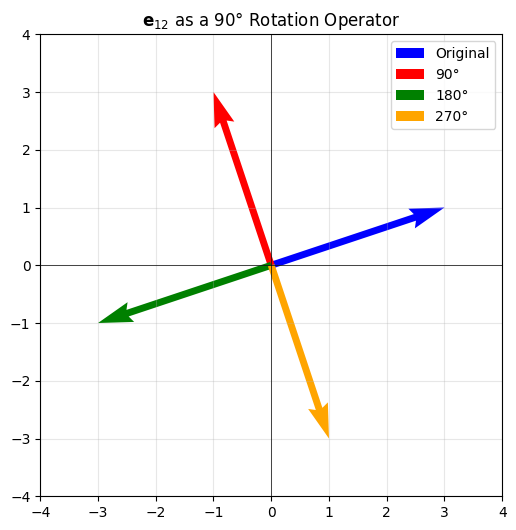

In [342]:
# Visualize the rotation
fig, ax = plt.subplots(figsize=(6, 6))

v = np.array([3.0, 1.0])
colors = ['blue', 'red', 'green', 'orange']
labels = ['Original', '90°', '180°', '270°']

for color, label in zip(colors, labels):
    ax.quiver(0, 0, v[0], v[1],
              angles='xy', scale_units='xy', scale=1,
              color=color, width=0.015, label=label)
    v = rotate_90_np(v)

ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.legend()
ax.set_title(r'$\mathbf{e}_{12}$ as a 90° Rotation Operator')
plt.show()

## 5.3 Building $\mathcal{C}\ell(2)$: The Three Rules

Everything in $\mathcal{C}\ell(2)$ follows from just three axioms:

| Rule | Meaning |
|------|--------|
| $\mathbf{e}_1^2 = 1$ | basis vector squares to +1 |
| $\mathbf{e}_2^2 = 1$ | basis vector squares to +1 |
| $\mathbf{e}_1 \mathbf{e}_2 = -\mathbf{e}_2 \mathbf{e}_1$ | anticommutativity |

Everything else — including $\mathbf{e}_{12}^2 = -1$ — is *derived* from these three.

In [343]:
# Basis vectors: non-commutative symbols
e1  = sp.Symbol('e1',  commutative=False)
e2  = sp.Symbol('e2',  commutative=False)
e12 = sp.Symbol('e12', commutative=False)

# Scalar coefficients: real numbers
s, a, b, c = sp.symbols('s a b c', real=True)

# A general multivector:
M = s + a*e1 + b*e2 + c*e12
print(f"General multivector: {M}")


def apply_rules(expr):
    """Apply the three GA axioms (and derived identities) to a SymPy expression."""
    return expr \
        .subs(e1*e1,    1)   \
        .subs(e2*e2,    1)   \
        .subs(e1*e2,    e12) \
        .subs(e2*e1,   -e12) \
        .subs(e12*e12,  -1)  \
        .subs(e12*e1,   e2)  \
        .subs(e12*e2,  -e1)  \
        .subs(e1*e12,  -e2)  \
        .subs(e2*e12,   e1)

print("\napply_rules() defined!")

General multivector: a*e1 + b*e2 + c*e12 + s

apply_rules() defined!


In [344]:
# Verify key identities

# e12² = -1 ?
expr = sp.expand(e12 * e12)
print(f"e12² = {apply_rules(expr)}")  # -1 ✓

# Geometric product of two vectors:
# u = 2*e1 + e2,  v = e1 + 2*e2
u = 2*e1 + e2
v = e1 + 2*e2
uv = apply_rules(sp.expand(u * v))
print(f"(2e1 + e2)(e1 + 2e2) = {uv}")  # 4 + 3*e12 ✓

# e12 rotates e1 by 90°?
print(f"e12 · e1 = {apply_rules(sp.expand(e12 * e1))}")  # e2  ✓
print(f"e12 · e2 = {apply_rules(sp.expand(e12 * e2))}")  # -e1 ✓

e12² = -1
(2e1 + e2)(e1 + 2e2) = 4 + 3*e12
e12 · e1 = e2
e12 · e2 = -e1


In [345]:
# Why not just use commutative=False alone?

# Without apply_rules:
print(f"Without apply_rules:")
print(f"  e12 * e12 = {sp.expand(e12 * e12)}")  # e12**2 (doesn't know it's -1)
print(f"  e1 * e2   = {sp.expand(e1 * e2)}")    # e1*e2 (doesn't know it's e12)

print(f"\nWith apply_rules:")
print(f"  e12 * e12 = {apply_rules(sp.expand(e12 * e12))}")  # -1
print(f"  e1 * e2   = {apply_rules(sp.expand(e1 * e2))}")    # e12

print("\ncommutative=False only preserves ORDER.")
print("apply_rules() encodes the ALGEBRA.")
print("\nNext class: wrap this into a proper Multivector class")
print("with __mul__ doing apply_rules automatically!")

Without apply_rules:
  e12 * e12 = e12**2
  e1 * e2   = e1*e2

With apply_rules:
  e12 * e12 = -1
  e1 * e2   = e12

commutative=False only preserves ORDER.
apply_rules() encodes the ALGEBRA.

Next class: wrap this into a proper Multivector class
with __mul__ doing apply_rules automatically!


---
# Proposed Exercises

Eight exercises covering the full Class 3 material. Try to solve each one before looking at the solution!

---

**Exercise 1 (OOP / Inheritance):** `UnitVector` — a subclass of `Vector2D` that always stores a normalised vector.

**Exercise 2 (Decorators):** `@memoize` — write a general caching decorator and apply it to an angle computation.

**Exercise 3 (Generators):** Archimedean spiral stream — generate an infinite stream of vectors along a spiral.

**Exercise 4 (Exceptions & Context Manager):** `ZeroVectorError` & `vector_precision`

**Exercise 5 (Pandas):** Vector dataset — load vectors into a DataFrame, compute stats per quadrant, visualise.

**Exercise 6 (SymPy):** Prove the Pythagorean identity for the geometric product symbolically.

**Exercise 7 (Synthesis — Functional + Generators + Pandas):** Build a lazy pipeline that filters, transforms, and summarises a large field of vectors without ever storing them all in memory.

## Exercise 1 — OOP / Inheritance: `UnitVector` subclass

Create a class `UnitVector` that:

1. Inherits from `Vector2D`.
2. In `__init__`, takes `(x, y)` and **automatically normalises** the input so the stored vector always has magnitude 1. Raise a `ValueError` if the zero vector is passed.
3. Overrides `__repr__` to show `UnitVector(...)` with 4 decimal places.
4. Adds a `@classmethod from_angle(cls, theta_deg)` that constructs a unit vector pointing at angle `theta_deg` (measured in degrees from the positive $x$-axis).
5. Verify that the `+` operator (inherited from `Vector2D`) *still normalises the result* — explain why this happens and whether it is the behaviour you want.


In [346]:
# Your solution here


### Solution — Exercise 1


In [347]:
class UnitVector(Vector2D):
    """A Vector2D that is always normalised to magnitude 1."""

    def __init__(self, x, y):
        mag = (x**2 + y**2)**0.5
        if mag == 0:
            raise ValueError("Cannot create a UnitVector from the zero vector.")
        # Normalise before passing to parent
        super().__init__(x / mag, y / mag)

    def __repr__(self):
        return f"UnitVector({self.x:.4f}, {self.y:.4f})"

    def __str__(self):
        return self.__repr__()

    @classmethod
    def from_angle(cls, theta_deg):
        """Construct a unit vector at angle theta_deg from the +x axis."""
        theta = np.radians(theta_deg)
        return cls(np.cos(theta), np.sin(theta))


# ── Tests ──────────────────────────────────────────────────────────────────
u = UnitVector(3, 4)
print(f"UnitVector(3, 4)  = {u}")
print(f"magnitude         = {u.magnitude():.6f}  (must be 1.0)")

u45 = UnitVector.from_angle(45)
print(f"from_angle(45deg) = {u45}")
print(f"magnitude         = {u45.magnitude():.6f}")

try:
    UnitVector(0, 0)
except ValueError as e:
    print(f"Zero vector: {e}")

# 5. What does + return?
u1 = UnitVector(1, 0)
u2 = UnitVector(0, 1)
s  = u1 + u2   # Vector2D.__add__ calls self.__class__(*a) = UnitVector(1, 1)
print(f"\nu1 + u2 = {s}")
print(f"type    = {type(s).__name__}")
print(f"mag     = {s.magnitude():.4f}")
print()
print("Why? self.__class__ is UnitVector, so __add__ calls UnitVector(1, 1),")
print("which normalises (1,1) -> (0.7071, 0.7071). The result IS a UnitVector,")
print("but it is the NORMALISED sum, not the true vector sum.")
print("This illustrates the risk of subclassing mutable/additive types.")


UnitVector(3, 4)  = UnitVector(0.6000, 0.8000)
magnitude         = 1.000000  (must be 1.0)
from_angle(45deg) = UnitVector(0.7071, 0.7071)
magnitude         = 1.000000
Zero vector: Cannot create a UnitVector from the zero vector.

u1 + u2 = UnitVector(0.7071, 0.7071)
type    = UnitVector
mag     = 1.0000

Why? self.__class__ is UnitVector, so __add__ calls UnitVector(1, 1),
which normalises (1,1) -> (0.7071, 0.7071). The result IS a UnitVector,
but it is the NORMALISED sum, not the true vector sum.
This illustrates the risk of subclassing mutable/additive types.


## Exercise 2 — Decorators: `@memoize`

Write a general-purpose `memoize` decorator that caches the return value of a function the first time it is called with a given set of arguments, and returns the cached value on subsequent calls.

1. Implement `memoize(func)` using a dictionary stored in the closure.
2. Apply it to `angle_between_deg(x1, y1, x2, y2)` — a plain function (not a method) that returns the angle between two 2D vectors in degrees.
3. Print a `"[computing ...]"` message *inside* `angle_between_deg` so you can see when it actually runs vs. when the cached value is returned.
4. Call with the same arguments twice — confirm the second call shows `"[cache hit]"` and does **not** print the computing message.


In [348]:
# Your solution here


### Solution — Exercise 2


In [349]:
def memoize(func):
    """Cache the result of a function for each unique set of arguments."""
    cache = {}
    def wrapper(*args, **kwargs):
        key = (args, tuple(sorted(kwargs.items())))
        if key not in cache:
            cache[key] = func(*args, **kwargs)
        else:
            print(f"  [cache hit for {func.__name__}{args}]")
        return cache[key]
    wrapper.__name__ = func.__name__
    return wrapper


@memoize
def angle_between_deg(x1, y1, x2, y2):
    print(f"  [computing angle_between_deg({x1},{y1}, {x2},{y2})]")
    v1 = Vector2D(x1, y1)
    v2 = Vector2D(x2, y2)
    return v1.angle_between(v2, in_degrees=True)


# First call — must compute
print(f"Result 1: {angle_between_deg(3, 4, 1, 0):.2f} deg")

# Second call with the same args — must use cache
print(f"Result 2: {angle_between_deg(3, 4, 1, 0):.2f} deg")

# Different args — must compute again
print(f"Result 3: {angle_between_deg(1, 0, 0, 1):.2f} deg")


  [computing angle_between_deg(3,4, 1,0)]
Result 1: 53.13 deg
  [cache hit for angle_between_deg(3, 4, 1, 0)]
Result 2: 53.13 deg
  [computing angle_between_deg(1,0, 0,1)]
Result 3: 90.00 deg


## Exercise 3 — Generators: Archimedean Spiral Stream

An Archimedean spiral is parameterised by $r = a\theta$, giving Cartesian coordinates:

$$x = a\theta\cos(\theta), \quad y = a\theta\sin(\theta)$$

1. Write a generator function `spiral_stream(a=0.3, d_theta=0.2)` that **infinitely** yields `Vector2D` objects along the spiral, incrementing $\theta$ by `d_theta` each step.
2. Use `itertools.islice` to take the first **50** vectors from the stream.
3. Plot the tips of those 50 vectors as a scatter plot, colour-coded by step index.
4. Use a **generator expression** (not a list) to find the first vector in a fresh stream whose magnitude exceeds `4.0`.


In [350]:
# Your solution here


### Solution — Exercise 3


First point : Vector(0.0, 0.0)
Last  point : Vector(-2.7354532399879776, -1.0774486400006595)


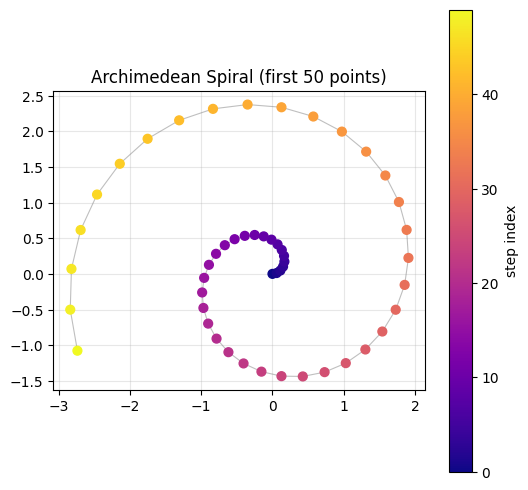


First spiral vector with |v| > 4 : Vector(2.702216195884986, 2.9763110776087967)
  magnitude = 4.0200


In [351]:
# 1. Infinite spiral generator
def spiral_stream(a=0.3, d_theta=0.2):
    """Yield Vector2D points along an Archimedean spiral r = a*theta."""
    theta = 0.0
    while True:
        r = a * theta
        yield Vector2D(r * np.cos(theta), r * np.sin(theta))
        theta += d_theta


# 2. Take first 50 vectors
spiral_pts = list(itertools.islice(spiral_stream(), 50))
print(f"First point : {spiral_pts[0]}")
print(f"Last  point : {spiral_pts[-1]}")

# 3. Scatter plot colour-coded by step index
xs = [v.x for v in spiral_pts]
ys = [v.y for v in spiral_pts]

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(xs, ys, c=range(50), cmap="plasma", s=40, zorder=3)
ax.plot(xs, ys, color="gray", linewidth=0.8, alpha=0.5)
plt.colorbar(sc, ax=ax, label="step index")
ax.set_aspect("equal")
ax.set_title("Archimedean Spiral (first 50 points)")
ax.grid(True, alpha=0.3)
plt.show()

# 4. Generator expression: first vector with magnitude > 4.0
# next() pulls the first item that satisfies the condition.
# The rest of the infinite stream is never evaluated — true lazy evaluation!
first_large = next(v for v in spiral_stream() if v.magnitude() > 4.0)
print(f"\nFirst spiral vector with |v| > 4 : {first_large}")
print(f"  magnitude = {first_large.magnitude():.4f}")


## Exercise 4 — Exceptions & Context Manager: `ZeroVectorError` & `vector_precision`

1. Define a custom exception `ZeroVectorError(Exception)` whose message includes the class name of the offending vector.
2. Patch `Vector2D.normalize` so it raises `ZeroVectorError` instead of a generic `ValueError`.
3. Write a `@contextmanager` called `vector_precision(n)` that:
   - Temporarily overrides `Vector2D.__str__` to print coordinates rounded to `n` decimal places.
   - Always restores the original `__str__` on exit, even if an exception is raised inside the `with` block.
4. Demonstrate all scenarios:
   - Normalising a **non-zero** vector (works normally).
   - Normalising the **zero** vector *without* a context manager (exception raised and caught).
   - Using `vector_precision(2)` to print vectors at reduced precision, then confirm the original `__str__` is restored afterwards.

In [352]:
# Your solution here


### Solution — Exercise 4


In [353]:
# 1. Custom exception
class ZeroVectorError(Exception):
    """Raised when attempting to normalise a zero vector."""
    def __init__(self, cls_name):
        super().__init__(f"Cannot normalise a zero {cls_name}.")


# 2. Patch Vector2D.normalize
def _normalize_patched(self):
    mag = self.magnitude()
    if mag == 0:
        raise ZeroVectorError(type(self).__name__)
    return self.__class__(*(self._array / mag))

Vector2D.normalize = _normalize_patched


# 3. Context manager
@contextmanager
def vector_precision(n):
    """Temporarily override Vector2D.__str__ to n decimal places."""
    original = Vector2D.__str__
    Vector2D.__str__ = lambda self: f"Vector2D({self.x:.{n}f}, {self.y:.{n}f})"
    try:
        yield
    finally:
        Vector2D.__str__ = original   # always restore, even on exception


# 4. Demonstrations
print("=== Scenario A: non-zero vector ===")
print(f"  normalize(3,4) = {Vector2D(3, 4).normalize()}")

print("\n=== Scenario B: zero vector, no context manager ===")
try:
    Vector2D(0, 0).normalize()
except ZeroVectorError as e:
    print(f"  Caught ZeroVectorError: {e}")

print("\n=== Scenario C: vector_precision context manager ===")
v = Vector2D(1/3, 2**0.5)
print(f"  Before: {v}")
with vector_precision(2):
    print(f"  Inside (n=2): {v}")
    print(f"  Inside (n=2): {Vector2D(1/7, 1/6)}")
print(f"  After:  {v}")   # original __repr__ restored

=== Scenario A: non-zero vector ===
  normalize(3,4) = Vector(0.6, 0.8)

=== Scenario B: zero vector, no context manager ===
  Caught ZeroVectorError: Cannot normalise a zero Vector2D.

=== Scenario C: vector_precision context manager ===
  Before: Vector(0.3333333333333333, 1.4142135623730951)
  Inside (n=2): Vector2D(0.33, 1.41)
  Inside (n=2): Vector2D(0.14, 0.17)
  After:  Vector(0.3333333333333333, 1.4142135623730951)


## Exercise 5 — Pandas: Vector Dataset Analysis

You are given 30 randomly-generated 2D vectors (seeded for reproducibility).

1. Build a Pandas DataFrame with columns `x`, `y`. Add computed columns:
   - `mag` — Euclidean magnitude.
   - `angle_deg` — angle to $+x$ axis in degrees (`np.degrees(np.arctan2(y, x))`).
   - `quadrant` — integer 1–4 based on the signs of `x` and `y`.
2. Use `.value_counts()` to count how many vectors fall in each quadrant.
3. Use `.groupby("quadrant")` to compute the **mean** and **std** of `mag` per quadrant.
4. Plot all 30 vectors as arrows with `ax.quiver`, colouring each quadrant differently. Add a legend.
5. *(Bonus)* Print the 5 longest vectors sorted by `mag` descending.


In [354]:
# Your solution here


### Solution — Exercise 5


In [355]:
random.seed(7)
N = 30

# 1. Build DataFrame
df5 = pd.DataFrame({
    "x": [random.uniform(-5, 5) for _ in range(N)],
    "y": [random.uniform(-5, 5) for _ in range(N)],
})
df5["mag"]       = (df5["x"]**2 + df5["y"]**2)**0.5
df5["angle_deg"] = np.degrees(np.arctan2(df5["y"], df5["x"]))

def _quadrant(row):
    if row.x >= 0 and row.y >= 0: return 1
    if row.x <  0 and row.y >= 0: return 2
    if row.x <  0 and row.y <  0: return 3
    return 4

df5["quadrant"] = df5.apply(_quadrant, axis=1)
print(df5.head())

# 2. Count per quadrant
print("\nVectors per quadrant:")
print(df5["quadrant"].value_counts().sort_index())

# 3. Magnitude stats per quadrant
print("\nMag stats per quadrant:")
print(df5.groupby("quadrant")["mag"].agg(["mean", "std"]).round(3))


          x         y       mag   angle_deg  quadrant
0 -1.761672  1.389135  2.243476  141.743097         2
1 -3.491508 -1.276025  3.717374 -159.924404         3
2  1.509345  0.477445  1.583059   17.553506         1
3 -4.275637 -4.372110  6.115261 -134.360842         3
4  0.358820 -4.403988  4.418582  -85.342049         4

Vectors per quadrant:
quadrant
1     8
2     7
3    12
4     3
Name: count, dtype: int64

Mag stats per quadrant:
           mean    std
quadrant              
1         3.301  2.118
2         3.068  1.211
3         4.463  1.072
4         2.941  1.952


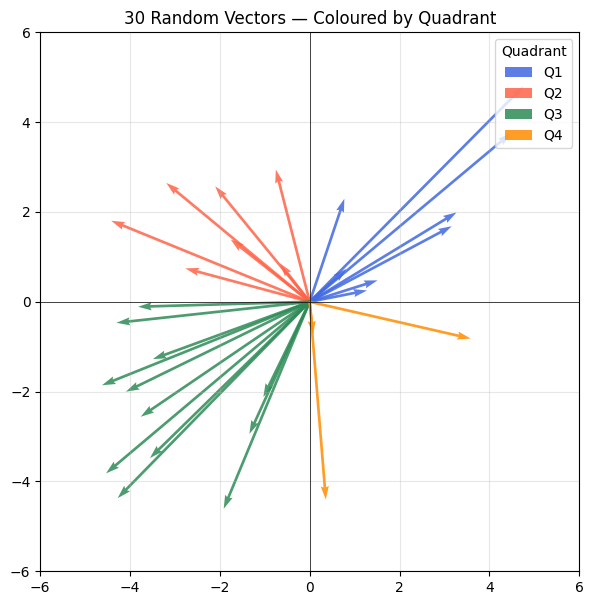


5 longest vectors:
        x      y    mag  quadrant
20  4.763  4.802  6.763         1
3  -4.276 -4.372  6.115         3
21 -4.534 -3.819  5.928         3
17  4.477  3.751  5.841         1
26 -1.915 -4.608  4.990         3


In [356]:
# 4. Quiver plot coloured by quadrant
quad_colors = {1: "royalblue", 2: "tomato", 3: "seagreen", 4: "darkorange"}

fig, ax = plt.subplots(figsize=(7, 7))

for q, grp in df5.groupby("quadrant"):
    ax.quiver(
        np.zeros(len(grp)), np.zeros(len(grp)),
        grp["x"].values, grp["y"].values,
        angles="xy", scale_units="xy", scale=1,
        color=quad_colors[q], alpha=0.85,
        width=0.005, label=f"Q{q}"
    )

ax.axhline(0, color="k", linewidth=0.5)
ax.axvline(0, color="k", linewidth=0.5)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
ax.legend(title="Quadrant")
ax.set_title("30 Random Vectors — Coloured by Quadrant")
plt.show()

# 5. Bonus: 5 longest
print("\n5 longest vectors:")
print(df5.sort_values("mag", ascending=False)
         .head()[["x", "y", "mag", "quadrant"]]
         .round(3))


## Exercise 6 — SymPy: Pythagorean Identity via the Geometric Product

For a 2D vector $\mathbf{v} = v_x \mathbf{e}_1 + v_y \mathbf{e}_2$, the self-product should give:
$$\mathbf{v}\mathbf{v} = |\mathbf{v}|^2 = v_x^2 + v_y^2$$

Use SymPy (and the `apply_rules` helper from Part 5) to:

1. Declare `vx, vy` as real symbols and `e1, e2, e12` as non-commutative symbols.
2. Compute $\mathbf{v}\mathbf{v}$ by expanding `(vx*e1 + vy*e2)**2` and calling `apply_rules`.
3. Show that the result is the **pure scalar** $v_x^2 + v_y^2$ — no bivector part.
4. Verify that the **anticommutator** $\mathbf{u}\mathbf{v} + \mathbf{v}\mathbf{u} = 2(\mathbf{u} \cdot \mathbf{v})$ holds symbolically.

In [357]:
# Your solution here


### Solution — Exercise 6


In [358]:
# 1. Symbols
e1  = sp.Symbol("e1",  commutative=False)
e2  = sp.Symbol("e2",  commutative=False)
e12 = sp.Symbol("e12", commutative=False)

vx, vy = sp.symbols("vx vy", real=True)
ux, uy = sp.symbols("ux uy", real=True)

v_vec = vx*e1 + vy*e2
u_vec = ux*e1 + uy*e2

# 2. Self-product v*v
vv = apply_rules(sp.expand(v_vec * v_vec))
print(f"v*v = {vv}")
# Expected: vx**2 + vy**2  — pure scalar, Pythagorean theorem!

# 3. Confirm no bivector part
e12_coeff = sp.collect(vv, e12).coeff(e12)
print(f"Coefficient of e12 in v*v: {e12_coeff}")  # 0

# 4. Anticommutator: u*v + v*u = 2*(u.v)
uv       = apply_rules(sp.expand(u_vec * v_vec))
vu       = apply_rules(sp.expand(v_vec * u_vec))
anticomm = sp.expand(uv + vu)
dot_2uv  = 2*(ux*vx + uy*vy)
print(f"\nu*v + v*u     = {anticomm}")
print(f"2*(u.v)       = {dot_2uv}")
print(f"Equal?        = {sp.simplify(anticomm - dot_2uv) == 0}")
# True — the anticommutator is always a pure scalar equal to 2*(u.v)  checkmark


v*v = vx**2 + vy**2
Coefficient of e12 in v*v: 0

u*v + v*u     = 2*ux*vx + 2*uy*vy
2*(u.v)       = 2*ux*vx + 2*uy*vy
Equal?        = True


## Exercise 7 — Synthesis: Lazy Vector Pipeline

Process a large stream of vectors **without ever storing them all in memory**.

A helper generator `random_vector_stream(n, seed)` is provided — do not change it.

1. Build a **generator expression** that lazily keeps only vectors whose `magnitude()` is in the range $(1, 4)$.
2. From that filtered stream, use `map` + a `lambda` to compute `(v, angle_deg)` pairs, where `angle_deg` is the angle to `e1_ref = Vector2D(1, 0)` in degrees.
3. Use `itertools.islice` to materialise the **first 10** pairs.
4. Load those 10 results into a Pandas DataFrame with columns `"repr"`, `"magnitude"`, `"angle_deg"`. Sort by `angle_deg` ascending and print.
5. On a **separate, fresh pass** of the stream, use `reduce` to find the vector with the **maximum dot product with `e1_ref`** (the one pointing most along $+x$).

*Key question:* why do steps 1–4 require a fresh generator for step 5?


In [359]:
def random_vector_stream(n, seed=0):
    """Yield n random Vector2D objects."""
    rng = random.Random(seed)
    for _ in range(n):
        yield Vector2D(rng.uniform(-5, 5), rng.uniform(-5, 5))

# Your solution here (steps 1-5)


### Solution — Exercise 7


In [360]:
e1_ref = Vector2D(1, 0)

# 1. Generator expression: filter by magnitude in (1, 4)
filtered = (
    v for v in random_vector_stream(200, seed=99)
    if 1.0 < v.magnitude() < 4.0
)

# 2. map + lambda: attach angle to each surviving vector
with_angles = map(
    lambda v: (v, v.angle_between(e1_ref, in_degrees=True)),
    filtered
)

# 3. Materialise first 10 pairs
first_10 = list(itertools.islice(with_angles, 10))

# 4. DataFrame, sorted by angle
df7 = pd.DataFrame([
    {
        "repr":      repr(v),
        "magnitude": round(v.magnitude(), 4),
        "angle_deg": round(ang, 2),
    }
    for v, ang in first_10
])
print(df7.sort_values("angle_deg").reset_index(drop=True).to_string())


                                                 repr  magnitude  angle_deg
0  Vector2D(2.7447356349082455, -0.30960952368537065)     2.7621       6.44
1   Vector2D(3.4996719335701325, -1.6119326589282235)     3.8531      24.73
2    Vector2D(2.5987743650807795, -2.488489916247799)     3.5981      43.76
3   Vector2D(1.1321606180375188, -2.8330768799324337)     3.0509      68.22
4   Vector2D(-0.9602192505633367, -2.999245554250546)     3.1492     107.75
5   Vector2D(-0.9737727014235062, -2.306007850322729)     2.5032     112.89
6  Vector2D(-1.4247507505759804, -2.8417669272105828)     3.1789     116.63
7     Vector2D(-1.118881489225314, 1.823688165291463)     2.1396     121.53
8   Vector2D(-1.1693241796782172, 1.8430863842731862)     2.1827     122.39
9     Vector2D(-3.47723465699827, 1.6056789591164113)     3.8301     155.21


In [361]:
# 5. Separate pass: find vector most aligned with e1 (max dot product)
# The previous generator is exhausted after step 3 — must create a fresh one!
most_aligned = reduce(
    lambda a, b: a if a.dot(e1_ref) >= b.dot(e1_ref) else b,
    random_vector_stream(200, seed=99)
)
print(f"Most aligned with e1 : {most_aligned}")
print(f"  dot(e1)            = {most_aligned.dot(e1_ref):.4f}")
print(f"  angle              = {most_aligned.angle_between(e1_ref, in_degrees=True):.2f} deg")

print("\nKey insight: generators are single-use cursors.")
print("After islice consumed items in step 3, the cursor is advanced.")
print("Step 5 needs an independent cursor -> fresh call to random_vector_stream().")


Most aligned with e1 : Vector(4.918209006168585, 2.936193376381773)
  dot(e1)            = 4.9182
  angle              = 30.84 deg

Key insight: generators are single-use cursors.
After islice consumed items in step 3, the cursor is advanced.
Step 5 needs an independent cursor -> fresh call to random_vector_stream().


## Exercise 8 — Capstone: `Multivector` class for $\\mathcal{C}\\ell(2)$

Build a `Multivector` class that encodes the full algebra of $\\mathcal{C}\\ell(2)$.
A multivector is stored as four real coefficients `(s, a, b, c)` representing
$s + a\\mathbf{e}_1 + b\\mathbf{e}_2 + c\\mathbf{e}_{12}$.

**Requirements:**

1. `__init__(self, s=0, a=0, b=0, c=0)` — store the four grade components.
2. `__repr__` — pretty-print showing only non-zero terms (e.g. `"1 + 2e1 - e12"`).
3. `__add__` and `__sub__` — grade-wise addition and subtraction. Also support adding a plain scalar.
4. `__mul__` — the **full geometric product** using the closed-form multiplication table:

   | | $1$ | $\\mathbf{e}_1$ | $\\mathbf{e}_2$ | $\\mathbf{e}_{12}$ |
   |---|---|---|---|---|
   | $\\mathbf{e}_1$ | $\\mathbf{e}_1$ | $1$ | $\\mathbf{e}_{12}$ | $-\\mathbf{e}_2$ |
   | $\\mathbf{e}_2$ | $\\mathbf{e}_2$ | $-\\mathbf{e}_{12}$ | $1$ | $\\mathbf{e}_1$ |
   | $\\mathbf{e}_{12}$ | $\\mathbf{e}_{12}$ | $\\mathbf{e}_2$ | $-\\mathbf{e}_1$ | $-1$ |

5. `reverse` property — the **reverse** $\\tilde{M}$ negates the bivector part: $(s,a,b,c)\\to(s,a,b,-c)$.
6. `scalar_part`, `vector_part`, `bivector_part` properties.

**Verification** (your code must produce all the expected values below):

- $\\mathbf{e}_1^2 = 1$, $\\mathbf{e}_2^2 = 1$, $\\mathbf{e}_{12}^2 = -1$
- $\\mathbf{e}_1\\mathbf{e}_2 = \\mathbf{e}_{12}$, $\\mathbf{e}_2\\mathbf{e}_1 = -\\mathbf{e}_{12}$, $\\mathbf{e}_1\\mathbf{e}_2 + \\mathbf{e}_2\\mathbf{e}_1 = 0$
- $(2\\mathbf{e}_1 + \\mathbf{e}_2)(\\mathbf{e}_1 + 2\\mathbf{e}_2) = 4 + 3\\mathbf{e}_{12}$
- Rotor $R = \\cos(45°) - \\sin(45°)\\mathbf{e}_{12}$ satisfies $R\\tilde{R} = 1$
- Sandwich $R\\,\\mathbf{e}_1\\,\\tilde{R} = \\mathbf{e}_2$ (rotation by $2 \\times 45° = 90°$)
- Sandwich $R\\,(3\\mathbf{e}_1 + \\mathbf{e}_2)\\,\\tilde{R} = -\\mathbf{e}_1 + 3\\mathbf{e}_2$


---
# Summary

---

### Advanced Python
- **Inheritance** — Extend `Vector2D` to `Vector3D` using `super()` and `self.__class__`
- **Decorators** — `@staticmethod`, `@classmethod`, `@property`, custom decorators
- **Functional programming** — List/dict comprehensions, `lambda`, `map`, `filter`, `sorted`, `reduce`
- **Generators** — `yield`, generator expressions, `itertools.islice` for infinite streams
- **Exception handling** — `try/except/else/finally`, custom exceptions, `@contextmanager`

### Essential Libraries
- **Pandas** — DataFrames for structuring, filtering, and analysing vector datasets
- **SymPy** — Exact symbolic math, non-commutative symbols, and proving identities

### Entering $\mathcal{C}\ell(2)$
- The geometric product unifies dot and wedge: $\mathbf{uv} = \mathbf{u} \cdot \mathbf{v} + \mathbf{u} \wedge \mathbf{v}$
- $\mathbf{e}_{12}$ acts as a 90° rotation operator (since $\mathbf{e}_{12}^2 = -1$)
- `apply_rules()` encodes the three GA axioms in SymPy
- **Next class:** a proper `Multivector` class with `__mul__` doing `apply_rules` automatically!